#Autómatas Celulares en 1D

## Introducción a los Autómatas Celulares (AC)

Antes de hablar a fondo sobre las características de la simulación realizada en el presente informe. Vale la pena detenerme un momento en estudiar de dónde surge este concepto tan particular.

El nacimiento de este concepto nace aproximadamente durante el siglo XX. No se tiene una certeza sobre el origen exacto. Se sabe que la primera referencia que se tiene data de los años 50's cuando un matemático importante de la época, Stanislaw Utam, le recoemdnó a John Von Neuman su uso para sus investigaciones en su estudio sobre las limitaciones de la inferencia estadística cuando se aplicaban sobre ciertos datos en particular. A partir de esa mención, su uso se comenzó a popularizar poco a poco.

Ahora uno cabría hacerse la siguiente pregunta **¿Qué es un autómata celular?** Un autómata celular no es más que un algoritmo o estructura computacional basada en reglas locales. Más exactamente es una matriz de celdas dónde cada celda está comunicada únicamente con sus celdas vecinas. Cada celda tiene la particularidad de que cada une recibe un dato de entrada que les he ofrecido por su celda vecina, luego realizan un cómputo cambiando su estado interno y generan datos de salida que se le envía a sus vecinas de manera síncrona, es decir, todas excatamente a la vez. No hay un control central como lo suele haber en los sistemas de cómputo tradicionales, en cambio, toda la cadena de mando esta distribuida uniformanente y las decisiones se toman localmente.

La característica que hacen especiales a los autómatas celulares, es que son capaces de aportar o añadir en concepto de **espacio** a los algoritmos. Por lo cual se pueden modelar sistemas espaciales con evoluciones en el tiempo. Añadiendo una nueva dimensión de complejidad o libertad a los problemas.

Por último, a este tipo de estructuras se les llama autómatas celulares porque combinan la arquitectura espacial discreta y local de las celdas biológicas, con el comportamiento lógico, determinista y sincronizado de las máquinas computacionales (autómatas). Es un modelo que traduce el espacio en una cuadrícula y el tiempo en una cascada de cálculos locales simultáneos.

## Definicón y bases de un AC

Habiendo dado un contexto a lo que es la estructura que se está estudiando, es posible entrar un poco más en detalle en estudiar más formalmente lo que hace a un autómata celular, un autómata celular. En primer lugar, se retoma la definción que se dió anteriormente, aquella que espefica a un AC como **una matriz de celdas**. Esta matriz puede ser de dimensión n, dónde n es un número entero postivo. Se definirá de esa forma ya que (por lo menos para efectos de estudio de problemas simulados) cada dimensión corresponde a un grado de libertad del sistema a estudiar, por lo que una dimensión negativa carece de sentido bajo este contexto y además **n** no necesariamente está acotado; sobre el papel **n** puede ser un valor cualquiera (inclusive infinito), pero cuando se lleva a la realidad, el número máximo de dimensiones que puede tener un autómata celular dependerá del poder computaciones (hardware) que se disponga.

Sin embargo, lo que si será indefinido será el número de celdad que va a tener el AC. A lo largo de las **n** dimensiones se extenderán un número indefinido de celdas. Esto se hace así ya que se busca minizar lo máximo posible el efecto de los bordes ya que son puntos dónde se rompe la comunación entre las celdas al no haber más vecinas en las cercanias. Aunque otra manera de abordar este problema en los bordes es "unir" los bordes. El borde izquiero con el derecho, el borde superior con el inferior, etc. De manera que siempre haya una comucación entre todas las celdas.

De manera que un AC puede tener un tamaño indefinido pero no infinito (debido a la limitación computacional que se acaba de discutir). A su vez, la geometría de las celdas puede variar. No necesarimente deben ser cuadradas, pueden ser de geometrías variadas y su escogencia dependerá del problema que se quiere estudiar. Ya que cosas como el número de vecinos que tiene cada celda y el número que celdas que se puede meter en una determinada área va a depender la geometría escogida.

Para que las celdas sepan la ubicación de sus celdas vecinas (y hacerle saber que de hecho, dicha celda es su vecina) y puedan transmitir datos entre ellas, es necesario especificar un conjunto de coordenadas relativas referente a dichas celdas. Es decir, a las coordenadas de la celda actual (una celda cualquiera del array) se le suma las coordenadas relativas de la celda más cercana y de esa manera obtener las celdas vecinas a la celda actual.

Anteriormente, se discutió el hecho de que la dimensión de un AC es acotado bajo el contexto de que el agoritmo debe ser ejecutable en una máquina, por lo que tamaño del mismo debe ser acorde a los recursos de hardware con los cuales se disponen. Esto se pueden extrapolar tambien a la cantidad de celdas que se pueden tener por cada dimnensión. Ya que aunque es indefinido, potencialmente puede llegar a ser infinito. Para poder solventar este problema se le exige al sistema que debe ser computable en un tiempo finito. Es decir, que el algoritmo sea capaz de resolver un problema y detenerse tras un número limitado de pasos. Entonces diremos que existe un estado de inactividad (tambien conocido como estado quiescente) en dónde no es necesario que se haga un cómputo en una celda cuyas celdas vecinas estén en el mismo estado. Además, el número de estados quiescente debe ser finito. Aunque el número de celdas disponibles se pueda extender a infinito, el número de celdas dónde hay que realizar cómputo es finito y debe ser finito. De esta manera se acoplar el concepto de espacio dentro de un algoritmo.

## Formalismo de un Autómata Celular

Formalmente, un AC se define formalmente como una tupla C definida como $C = \langle d, r, Q, \#, V, \delta \rangle$ dónde cada elemento de la tupla corresponde a:

1. **d** indica la dimensión del AC y cómo se ha discutido este viene definido en el intervalo $d \ge 1$

2. **r** indica el índice de localidad, es decir, el alcance visual que tiene una celda para interactuar con otras celdas. Este parámetro está definido en el intervalo $r \ge 0$.

3. **Q** indica el conjutno de estados del sistema.

4. **V** es un vector de vecindad definido como $V = (z_1, z_2, \dots, z_r) \subset (\mathbb{Z}^d)^r$. Más exactamente, **V** es un vector de desplazamiento relativo.

5. $\delta$ indica la regla de transición de un estado a otro y se define como $\delta : Q^{r+1} \to Q$.

6. $\# \in Q$ indica el estado quiescente. A raiz de lo que se ha discutido, por definición $\delta (\#. \#, \#, ..., \#) = \#$ es el estado que implica la ausencia de actividad.

7. Sea  $V = (z_1, z_2, \dots, z_r)$ entonces las **r** celdas vecinas de la celda $w$ se obtienen mediante sumas vectoriales de la forma $(w + z_1, w + z_2, \dots, w + z_r)$

## Clasificación y reglas de Wolfrang

De entre todos los científicos que abordaron los AC, hay uno de ellos que destaca en particular por su manera de estudiarlos, Stephen Wolfrang. Wolfrang decidió estudiar a los AC en su forma más simple posible, trabajando con autómatas de una dimensión y con dos estados posibles (0 y 1) y un vecindario de radio 1 (es decir, cada celda es capaz de ver una celda vecina a su derecha o izquierda).

Al estar el sistema de estudio restringuido por 3 celdas y dos estados posibles. Existen exactamente $2^{3} = 8$ combinaciones posibles (desde 000 hasta 111). A cada una de estas combianciones. el sistema asigna una de ellas para la siguiente generación. Al haber 8 resultados binarios posibles, hay un total de $2^{8} = 256$ reglas posibles.

Para evitarse complicaciones, Wolfrang ideó un ingenioso sistema de enumaración ordenando los 8 estados binarios posibles de mayor a menor y colocó el resultado de cada regla debajo. Al leer dicha fila de izquierda a derecha como un número y luego se convierte a decimal, se obtiene el número de la regla.

Luego en base a los comportamientos que mostrabam los AC al aplicarle cada regla. Wolfrang puedo diferenciarlos en 4 clases distintas:

### Clase 01: Evolución hacia la Homogeneidad

Los de esta clase tienen la característica de que el sistema colapsa hacia un estado estático y uniforme. Cualquier estructura inicial es destruida.

### Clase 02: Estructuras periódicas y predecibles

El sistema genera patrones que se repiten exactamente en el tiempo, o que forman estructuras geómetricas simples que no interactpuan entre sí.

### Clase 03: Caos determinista

El sistema a partir de condiciones iniciales simples, se generan patrones completmente aleatorios. No hay periodicidad, pero el sistema esta regido por reglas exactas (deterministas)

### Clase 04: El borde del caos

Se podría decir que esta es la clase más particular de todas. A diferencia de las clases anteiores, el sistema no se congela ni explota en caos- En su lugar crea estructuras localizadas que se mueven, sobreviven al paso del tiempo y colisionan entre sí de formas complejas.  

## Simulación

En el presente informe se muestra una simulación interactiva. Consta de una interfaz en dónde el usuario es capaz de elegir libremente entre las 4 clases que se mencionaron anteriormente y será capaz de elegir entre dos reglas por clase. De entre las reglas escogidas para cada clase se tienen las siguientes:

### Reglas para la clase 01:

#### Regla 0:

Esta es la regla más destructuva posible. Su algoritmo dicta que ninguna celda (actual o vecina) resulta en un 1. Por lo tanto, independientemente del estado inicial, en el primer paso temporal todo se apaga.

#### Regla 255:

Esta regla es el extremo opuesto de la anterior. Su algoritmo dicta que toda celda (actual o vecina) resulta en un 1. Si una celda esta viva en $t=0$ entonces sus dos celdas vecinas estaran vivas, luego en $t=1$ las vecinas de esas vecinas se encienden, y así sucesivamente. Es una explosión geométrica que satura todo el espacio de vida.

### Reglas para la clase 02:

#### Regla 04:

Se define por el código binario 00000100, lo que significa que una celda solo se volverá negra (estado 1) en la siguiente generación si su configuración actual es blanco-negro-blanco (\(010\)


#### Regla 108:

Esta regla funciona como un filtro geométrico que dicta la muerte inmediata de cualquier celda aislada, pero permite la expansión de bloques de dos celdas contiguas. Al evolucionar desde un estado inicial con ruido, en t=1 los bordes de estos bloques sobrevivientes comienzan a desplazarse hacia los lados. A medida que avanza el tiempo, estos frentes en expansión colisionan entre sí, pero en lugar de generar caos, la regla los detiene y anula de manera predecible, formando triángulos y estructuras que se repiten exactamente cada cierta cantidad de generaciones, creando un patrón rítmico y estable.

### Reglas para la clase 03:

#### Regla 30:

El algoritmo de esta regla genera caos a través de una asimetría calculada: permite que una celda aislada sobreviva, pero destruye implacablemente cualquier agrupación densa de tres celdas. Si partimos de una sola celda viva en
t=0
, en
t=1
 esta sobrevive y genera vida a sus costados, pero en
t=2
 esa nueva agrupación hace que el centro colapse. Este colapso continuo divide la estructura en dos frentes; el derecho forma un triángulo limpio y periódico, pero el izquierdo choca constantemente con los escombros de generaciones anteriores, creando una retroalimentación impredecible que degrada el patrón en un ruido visual que parece completamente aleatorio.

#### Regla 45:

Esta regla es un motor de fluctuación continua porque su algoritmo dicta una anomalía: el vacío absoluto de tres celdas muertas espontáneamente genera vida. Al evolucionar desde una sola celda, en
t=1
 no solo sobrevive, sino que el espacio muerto a su alrededor se llena rápidamente. A medida que el tiempo avanza, el espacio se satura de celdas, lo que activa la otra cara de la regla: las altas densidades provocan muertes masivas. El resultado es una guerra constante y difusa entre la vida nacida de la nada y la muerte provocada por el amontonamiento, llenando la cuadrícula de un ruido estático simétrico y de altísima entropía.

### Reglas para la clase 04:

#### Regla 54:

Esta regla opera en el borde del caos creando un universo de partículas viajeras sobre un fondo estático, ya que dicta que tanto el vacío como la plenitud absoluta mueran. Al evolucionar, la celda inicial forma rápidamente un patrón de pequeños triángulos periódicos que actúan como un éter de fondo. Sin embargo, cuando las condiciones de frontera rompen este patrón en generaciones posteriores, ciertos vecindarios toman el control y comienzan a escupir celdas hacia los lados, creando líneas diagonales blancas que se desplazan a velocidad constante, colisionando entre ellas, rebotando o anulándose sin destruir el fondo, simulando un tráfico de información perfectamente estructurado.

#### Regla 110:

Esta es la regla más compleja de todas, matemáticamente demostrada como una computadora universal, y su algoritmo logra esto invirtiendo sutilmente la dirección de expansión de la Regla 54. Al evolucionar, no genera un fondo de triángulos simples, sino un éter denso y altamente estructurado que parece una textura de ladrillos diagonales. Sobre este fondo caótico pero estable, la regla propulsa estructuras viajeras mucho más robustas; cuando estas estructuras colisionan, no solo rebotan, sino que alteran el tejido del éter circundante de forma que la secuencia de choques actúa como un cableado lógico, capaz de procesar y almacenar información binaria de forma autónoma.

#Librerias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image, ImageDraw
from google.colab import files
import io
from scipy.ndimage import gaussian_filter
import matplotlib.animation as animation
import matplotlib.colors
import matplotlib.gridspec as gridspec
from scipy.signal import convolve2d
from IPython.display import HTML

## Documentación de las librerias

Para realizar los algoritmos que se muestran en el presente informe, se utilizaron las siguientes librerias:

## 1. Librerías de Cómputo Numérico y Científico

### `import numpy as np`
* **Descripción:** Librería fundamental para el cómputo matricial y vectorial en Python.
* **Justificación en el Proyecto:** * **Representación del Grid:** Las estructuras de los autómatas (tanto vectores $1D$ como matrices $2D$) se manejan como arreglos de NumPy (`np.ndarray`) para optimizar el uso de memoria.
  * **Operaciones Bitwise y Lógicas:** Permite aplicar las reglas de evolución simultáneamente en todo el arreglo mediante indexación avanzada y máscaras booleanas, evitando bucles `for` lentos en Python.
  * **Cálculo Matemático:** Proporciona funciones clave como `np.log2` para el cálculo de entropías y funciones estadísticas como `np.mean` o `np.sum` para calcular la densidad de celdas activas.

### `from scipy.signal import convolve2d`
* **Descripción:** Herramienta específica de procesamiento de señales dentro del ecosistema SciPy para realizar convoluciones en dos dimensiones.
* **Justificación en el Proyecto:** * Es el núcleo del **Modelo de Incendio Forestal** y del **Detector de Bordes**. En lugar de evaluar los vecinos de cada celda de forma iterativa, se define una matriz pequeña (kernel) y se realiza una convolución en $2D$. Esto permite calcular el estado de la vecindad de Moore o von Neumann de todo el grid de forma masivamente paralela y eficiente.

### `from scipy.ndimage import gaussian_filter`
* **Descripción:** Filtro de suavizado espacial basado en una distribución Gaussiana.
* **Justificación en el Proyecto:** * Crucial para el algoritmo de **detector de bordes usando AC**. Antes de someter una imagen real a las reglas de un autómata celular, se aplica este filtro para reducir el ruido de alta frecuencia y los artefactos, garantizando que el autómata detecte bordes estructurales reales y no variaciones aleatorias de píxeles.

---

## 2. Librerías de Visualización y Gráficos

### `import matplotlib.pyplot as plt`
* **Descripción:** Interfaz de trazado de gráficos estándar de facto en el ecosistema científico de Python.
* **Justificación en el Proyecto:** * Se utiliza para generar el "espacio-tiempo" de los AC $1D$ (diagramas donde el eje $X$ es el espacio y el eje $Y$ es el tiempo) mediante `plt.imshow()`, y para graficar la evolución temporal de las métricas (entropía, densidad, parámetros).

### `import matplotlib.colors`
* **Descripción:** Módulo interno de Matplotlib encargado de la gestión, mapeo y normalización de colores.
* **Justificación en el Proyecto:** * Esencial en simulaciones multiestado (como el incendio forestal: *Vacío, Árbol, Fuego*). Permite crear mapas de colores discretos personalizados (`colors.ListedColormap`) para asociar explícitamente un color a cada estado del autómata celular.

### `import matplotlib.gridspec as gridspec`
* **Descripción:** Estructura que permite organizar subgráficos (`subplots`) en una cuadrícula con control total sobre las proporciones de filas y columnas.
* **Justificación en el Proyecto:** * Se utiliza para diseñar el **Dashboard dinámico**. Permite colocar, en una sola ventana visual, la simulación del autómata celular en un tamaño grande y, a su lado o debajo, gráficos más pequeños con el comportamiento en tiempo real de la entropía, la distancia de Hamming o el parámetro de Langton.

---

## 3. Animación y Despliegue Multimedia

### `import matplotlib.animation as animation`
* **Descripción:** Framework de Matplotlib diseñado para crear animaciones frame por frame a partir de funciones que actualizan datos dinámicamente.
* **Justificación en el Proyecto:** * Controla el bucle de renderizado temporal de las simulaciones en $2D$. En lugar de imprimir cientos de imágenes seguidas, esta librería compila la evolución del autómata en un único objeto de animación fluido.

### `from IPython.display import HTML`
* **Descripción:** Permite renderizar y embeber directamente código HTML dentro de las celdas de salida de Jupyter/Colab.
* **Justificación en el Proyecto:** * Convierte las animaciones generadas por `matplotlib.animation` en videos interactivos nativos de la web utilizando etiquetas HTML5 `<video>`, permitiendo pausar, adelantar y reproducir la simulación directamente en el navegador.

---

## 4. Interactividad y Control de Interfaz (GUI)

### `import ipywidgets as widgets`
* **Descripción:** Componentes visuales interactivos (sliders, botones, menús desplegables) para Jupyter Notebooks.
* **Justificación en el Proyecto:** * Proporciona la interfaz de usuario para configurar los experimentos sin modificar código. Permite cambiar interactivamente la regla de Wolfram (0-255), la probabilidad de caída de rayos en incendios, o los umbrales del detector de bordes mediante controles deslizantes.

### `from IPython.display import display, clear_output`
* **Descripción:** Funciones de control del sistema de visualización del kernel de IPython.
* **Justificación en el Proyecto:** * `display` se encarga de renderizar los componentes de `ipywidgets` en pantalla.
  * `clear_output(wait=True)` es una función crítica: borra la salida previa de la celda de Colab de manera síncrona justo antes de pintar el siguiente fotograma, evitando el parpadeo de pantalla (*flickering*) durante actualizaciones interactivas rápidas.

---

## 5. Procesamiento de Imágenes y Gestión de Archivos

### `from PIL import Image, ImageDraw`
* **Descripción:** *Python Imaging Library* (Pillow). Librería estándar para la apertura, manipulación, creación y guardado de formatos de imágenes rasterizadas.
* **Justificación en el Proyecto:** * Actúa como puente para el **detector de bordes**. Permite cargar imágenes externas, redimensionarlas, convertirlas a escala de grises (o binarias) y transformarlas en matrices numéricas aptas para ser la condición inicial del autómata celular. `ImageDraw` permite generar formas geométricas sintéticas dentro del código para probar el algoritmo.

### `from google.colab import files`
* **Descripción:** Módulo exclusivo del entorno de Google Colab para la interacción con el sistema local del usuario.
* **Justificación en el Proyecto:** * Permite abrir una ventana de diálogo nativa en el navegador para que el usuario pueda subir (`files.upload()`) sus propias fotos desde su computadora hacia el entorno de Colab para procesarlas con el detector de bordes.

### `import io`
* **Descripción:** Módulo de la biblioteca estándar de Python que maneja flujos de entrada y salida de datos en memoria (I/O).
* **Justificación en el Proyecto:** * Cuando se sube una imagen mediante `google.colab.files`, los datos se reciben en memoria como un buffer de bytes. `io.BytesIO` envuelve estos bytes para que la librería `PIL.Image` pueda interpretarlos y abrir la imagen directamente sin necesidad de guardarla primero en el disco duro virtual.



# Código sección 1

In [ ]:
def obtener_regla_binaria(numero_regla):
    return [int(bit) for bit in f"{numero_regla:08b}"]

def evolucionar_automata(numero_regla, generaciones, ancho=301, estado_inicial='unico'):
    regla_binaria = obtener_regla_binaria(numero_regla)
    grid = np.zeros((generaciones, ancho), dtype=np.uint8)

    if estado_inicial == 'unico':
        grid[0, ancho // 2] = 1
    elif estado_inicial == 'aleatorio':
        grid[0, :] = np.random.randint(0, 2, size=ancho)

    for t in range(1, generaciones):
        for x in range(ancho):
            izquierda = grid[t-1, (x-1) % ancho]
            centro     = grid[t-1, x]
            derecha    = grid[t-1, (x+1) % ancho]
            indice_vecindario = 4 * izquierda + 2 * centro + derecha
            nuevo_estado = regla_binaria[7 - indice_vecindario]
            grid[t, x] = nuevo_estado
    return grid

selector_regla = widgets.Dropdown(options=[0, 255], value=0, description='Regla Específica:', style={'description_width': 'initial'}, layout=widgets.Layout(width='300px'))
selector_estado = widgets.Dropdown(options=[('Una sola celda', 'unico'), ('Ruido Aleatorio', 'aleatorio')], value='unico', description='Condición Inicial:', style={'description_width': 'initial'}, layout=widgets.Layout(width='300px'))
slider_generaciones = widgets.IntSlider(value=50, min=10, max=100, step=5, description='Generaciones:', style={'description_width': 'initial'}, layout=widgets.Layout(width='500px'))
boton_ejecutar = widgets.Button(description='▶ Ejecutar Clase I', button_style='info', layout=widgets.Layout(width='300px'))
area_salida = widgets.Output()

def ejecutar_simulacion(b):
    with area_salida:
        clear_output(wait=True)
        matriz = evolucionar_automata(selector_regla.value, slider_generaciones.value, estado_inicial=selector_estado.value)
        plt.figure(figsize=(12, 4))
        plt.imshow(matriz, cmap='binary', aspect='auto', interpolation='nearest')
        plt.title(f'Clase I (Homogénea) - Regla {selector_regla.value}', fontsize=14, fontweight='bold')
        plt.xlabel('Espacio (Celdas)', fontsize=12)
        plt.ylabel('Tiempo', fontsize=12)
        plt.yticks([])
        plt.xticks([])
        plt.figtext(0.5, -0.02, f"Binario: {selector_regla.value:08b} | El sistema colapsa a un estado estático inmediato.", ha="center", fontsize=10, bbox=dict(facecolor='lightgray', alpha=0.8, edgecolor='gray'))
        plt.tight_layout()
        plt.show()

boton_ejecutar.on_click(ejecutar_simulacion)

display(widgets.VBox([
    widgets.HTML(value="<h3 style='color:blue;'>Simulador Clase I: Homogénea</h3>"),
    selector_regla, selector_estado, slider_generaciones, boton_ejecutar, area_salida
]))

In [ ]:
def obtener_regla_binaria(numero_regla):
    return [int(bit) for bit in f"{numero_regla:08b}"]

def evolucionar_automata(numero_regla, generaciones, ancho=301, estado_inicial='unico'):
    regla_binaria = obtener_regla_binaria(numero_regla)
    grid = np.zeros((generaciones, ancho), dtype=np.uint8)

    if estado_inicial == 'unico':
        grid[0, ancho // 2] = 1
    elif estado_inicial == 'aleatorio':
        grid[0, :] = np.random.randint(0, 2, size=ancho)

    for t in range(1, generaciones):
        for x in range(ancho):
            izquierda = grid[t-1, (x-1) % ancho]
            centro     = grid[t-1, x]
            derecha    = grid[t-1, (x+1) % ancho]
            indice_vecindario = 4 * izquierda + 2 * centro + derecha
            nuevo_estado = regla_binaria[7 - indice_vecindario]
            grid[t, x] = nuevo_estado
    return grid

selector_regla = widgets.Dropdown(options=[4, 108], value=4, description='Regla Específica:', style={'description_width': 'initial'}, layout=widgets.Layout(width='300px'))
selector_estado = widgets.Dropdown(options=[('Una sola celda', 'unico'), ('Ruido Aleatorio', 'aleatorio')], value='unico', description='Condición Inicial:', style={'description_width': 'initial'}, layout=widgets.Layout(width='300px'))
slider_generaciones = widgets.IntSlider(value=100, min=20, max=200, step=10, description='Generaciones:', style={'description_width': 'initial'}, layout=widgets.Layout(width='500px'))
boton_ejecutar = widgets.Button(description='▶ Ejecutar Clase II', button_style='info', layout=widgets.Layout(width='300px'))
area_salida = widgets.Output()

def ejecutar_simulacion(b):
    with area_salida:
        clear_output(wait=True)
        matriz = evolucionar_automata(selector_regla.value, slider_generaciones.value, estado_inicial=selector_estado.value)
        plt.figure(figsize=(12, 6))
        plt.imshow(matriz, cmap='binary', aspect='auto', interpolation='nearest')
        plt.title(f'Clase II (Periódica) - Regla {selector_regla.value}', fontsize=14, fontweight='bold')
        plt.xlabel('Espacio (Celdas)', fontsize=12)
        plt.ylabel('Tiempo', fontsize=12)
        plt.yticks([])
        plt.xticks([])
        plt.figtext(0.5, -0.02, f"Binario: {selector_regla.value:08b} | Estructuras que se repiten o filtros geométricos predecibles.", ha="center", fontsize=10, bbox=dict(facecolor='lightgray', alpha=0.8, edgecolor='gray'))
        plt.tight_layout()
        plt.show()

boton_ejecutar.on_click(ejecutar_simulacion)

display(widgets.VBox([
    widgets.HTML(value="<h3 style='color:green;'>Simulador Clase II: Periódica</h3>"),
    selector_regla, selector_estado, slider_generaciones, boton_ejecutar, area_salida
]))

In [ ]:
def obtener_regla_binaria(numero_regla):
    return [int(bit) for bit in f"{numero_regla:08b}"]

def evolucionar_automata(numero_regla, generaciones, ancho=301, estado_inicial='unico'):
    regla_binaria = obtener_regla_binaria(numero_regla)
    grid = np.zeros((generaciones, ancho), dtype=np.uint8)

    if estado_inicial == 'unico':
        grid[0, ancho // 2] = 1
    elif estado_inicial == 'aleatorio':
        grid[0, :] = np.random.randint(0, 2, size=ancho)

    for t in range(1, generaciones):
        for x in range(ancho):
            izquierda = grid[t-1, (x-1) % ancho]
            centro     = grid[t-1, x]
            derecha    = grid[t-1, (x+1) % ancho]
            indice_vecindario = 4 * izquierda + 2 * centro + derecha
            nuevo_estado = regla_binaria[7 - indice_vecindario]
            grid[t, x] = nuevo_estado
    return grid

selector_regla = widgets.Dropdown(options=[30, 45], value=30, description='Regla Específica:', style={'description_width': 'initial'}, layout=widgets.Layout(width='300px'))
selector_estado = widgets.Dropdown(options=[('Una sola celda', 'unico'), ('Ruido Aleatorio', 'aleatorio')], value='unico', description='Condición Inicial:', style={'description_width': 'initial'}, layout=widgets.Layout(width='300px'))
slider_generaciones = widgets.IntSlider(value=150, min=50, max=300, step=10, description='Generaciones:', style={'description_width': 'initial'}, layout=widgets.Layout(width='500px'))
boton_ejecutar = widgets.Button(description='▶ Ejecutar Clase III', button_style='info', layout=widgets.Layout(width='300px'))
area_salida = widgets.Output()

def ejecutar_simulacion(b):
    with area_salida:
        clear_output(wait=True)
        matriz = evolucionar_automata(selector_regla.value, slider_generaciones.value, estado_inicial=selector_estado.value)
        plt.figure(figsize=(12, 6))
        plt.imshow(matriz, cmap='binary', aspect='auto', interpolation='nearest')
        plt.title(f'Clase III (Caótica) - Regla {selector_regla.value}', fontsize=14, fontweight='bold')
        plt.xlabel('Espacio (Celdas)', fontsize=12)
        plt.ylabel('Tiempo', fontsize=12)
        plt.yticks([])
        plt.xticks([])
        plt.figtext(0.5, -0.02, f"Binario: {selector_regla.value:08b} | Apariencia de ruido pseudoaleatorio e impredecible.", ha="center", fontsize=10, bbox=dict(facecolor='lightgray', alpha=0.8, edgecolor='gray'))
        plt.tight_layout()
        plt.show()

boton_ejecutar.on_click(ejecutar_simulacion)

display(widgets.VBox([
    widgets.HTML(value="<h3 style='color:red;'>Simulador Clase III: Caótica</h3>"),
    selector_regla, selector_estado, slider_generaciones, boton_ejecutar, area_salida
]))

In [ ]:
def obtener_regla_binaria(numero_regla):
    return [int(bit) for bit in f"{numero_regla:08b}"]

def evolucionar_automata(numero_regla, generaciones, ancho=301, estado_inicial='unico'):
    regla_binaria = obtener_regla_binaria(numero_regla)
    grid = np.zeros((generaciones, ancho), dtype=np.uint8)

    if estado_inicial == 'unico':
        grid[0, ancho // 2] = 1
    elif estado_inicial == 'aleatorio':
        grid[0, :] = np.random.randint(0, 2, size=ancho)

    for t in range(1, generaciones):
        for x in range(ancho):
            izquierda = grid[t-1, (x-1) % ancho]
            centro     = grid[t-1, x]
            derecha    = grid[t-1, (x+1) % ancho]
            indice_vecindario = 4 * izquierda + 2 * centro + derecha
            nuevo_estado = regla_binaria[7 - indice_vecindario]
            grid[t, x] = nuevo_estado
    return grid

selector_regla = widgets.Dropdown(options=[54, 110], value=110, description='Regla Específica:', style={'description_width': 'initial'}, layout=widgets.Layout(width='300px'))
selector_estado = widgets.Dropdown(options=[('Una sola celda', 'unico'), ('Ruido Aleatorio', 'aleatorio')], value='unico', description='Condición Inicial:', style={'description_width': 'initial'}, layout=widgets.Layout(width='300px'))
slider_generaciones = widgets.IntSlider(value=200, min=50, max=300, step=10, description='Generaciones:', style={'description_width': 'initial'}, layout=widgets.Layout(width='500px'))
boton_ejecutar = widgets.Button(description='▶ Ejecutar Clase IV', button_style='info', layout=widgets.Layout(width='300px'))
area_salida = widgets.Output()

def ejecutar_simulacion(b):
    with area_salida:
        clear_output(wait=True)
        matriz = evolucionar_automata(selector_regla.value, slider_generaciones.value, estado_inicial=selector_estado.value)
        plt.figure(figsize=(12, 6))
        plt.imshow(matriz, cmap='binary', aspect='auto', interpolation='nearest')
        plt.title(f'Clase IV (Compleja) - Regla {selector_regla.value}', fontsize=14, fontweight='bold')
        plt.xlabel('Espacio (Celdas)', fontsize=12)
        plt.ylabel('Tiempo', fontsize=12)
        plt.yticks([])
        plt.xticks([])
        plt.figtext(0.5, -0.02, f"Binario: {selector_regla.value:08b} | Partículas locales que colisionan y transmiten información (Complejidad).", ha="center", fontsize=10, bbox=dict(facecolor='lightgray', alpha=0.8, edgecolor='gray'))
        plt.tight_layout()
        plt.show()

boton_ejecutar.on_click(ejecutar_simulacion)

display(widgets.VBox([
    widgets.HTML(value="<h3 style='color:purple;'>Simulador Clase IV: Compleja</h3>"),
    selector_regla, selector_estado, slider_generaciones, boton_ejecutar, area_salida
]))

## Documentación del código

Cada uno de los 4 algoritmos que se muestran en esta sección son en escencia el mismo algoritmo. Las diferencias entre cada uno radicarán en el resultado de la primera función **Obtener_regla_binaria**. A continuación se presenta una documentación técnica sobre el algoritmo en sí mismo.

### Dependencias

Para la ejecución de este código se requieren las siguientes librerías:

1. **Numpy** : Usado para el cálculo vectorial y el manejo eficiente de matrices.

2. **Matplotlib** : Usado para ekl renderizado gráfico (visualización) del AC.

3. **Ipython Widgests** :  Para creación de la interfaz interactiva (botones, sliders y menus desplegables)


#### `obtener_regla_binaria(numero_regla)`
**Descripción:** Convierte un número de regla entero (0–255) en una lista de 8 bits que representa la tabla de transición del autómata. El bit más significativo (índice 0) corresponde al vecindario `111` y el menos significativo (índice 7) al vecindario `000`.

**Funciones de librería utilizadas:**
- **`f"{numero_regla:08b}"` (formateo de cadenas, Python estándar):**  
  Convierte el entero a una cadena binaria de exactamente 8 caracteres, rellenando con ceros a la izquierda si es necesario. Internamente utiliza la representación binaria en complemento a dos para números no negativos.
- **`int(bit)` (constructor de Python):**  
  Convierte cada carácter de la cadena (`'0'` o `'1'`) en el entero correspondiente `0` o `1`.
- **Comprensión de lista `[...]`:**  
  Construye la lista resultante evaluando la expresión para cada carácter del iterable.

---

#### `evolucionar_automata(numero_regla, generaciones, ancho=301, estado_inicial='unico')`
**Descripción:** Genera la evolución espacio-temporal del autómata celular unidimensional con condiciones de frontera periódicas. Devuelve una matriz NumPy de forma `(generaciones, ancho)` donde cada fila representa una generación. Admite dos condiciones iniciales: una sola celda central activa (`'unico'`) o ruido aleatorio (`'aleatorio'`).

**Funciones de librería utilizadas dentro de esta función:**
- **`obtener_regla_binaria(numero_regla)` (función definida arriba):**  
  Obtiene la regla en forma de lista de 8 bits.
- **`np.zeros((generaciones, ancho), dtype=np.uint8)`:**  
  Crea una matriz de NumPy llena de ceros con las dimensiones especificadas. El argumento `dtype=np.uint8` define que cada celda se almacena como un entero sin signo de 8 bits (valores 0–255). Internamente asigna un bloque contiguo de memoria e inicializa todos los elementos a 0.
- **`np.random.randint(0, 2, size=ancho)`:**  
  Genera un arreglo de `ancho` números enteros aleatorios en el intervalo semiabierto `[0, 2)`, es decir, 0 o 1. Utiliza el generador pseudoaleatorio de NumPy (PCG-64 o Mersenne Twister según la configuración) para producir una secuencia uniforme.
- **Operador módulo `% ancho`:**  
  Se usa para implementar condiciones de frontera periódicas: `(x-1) % ancho` y `(x+1) % ancho`. En Python, el operador `%` devuelve el resto de la división, garantizando que el índice resultante esté siempre dentro del rango `[0, ancho-1]`, incluso cuando `x-1` es negativo (el módulo en Python devuelve un número no negativo).
- **`grid[t-1, ...]` (indexación de arreglos NumPy):**  
  Accede a los elementos de la fila anterior. La indexación multidimensional es rápida porque NumPy utiliza vistas sobre los datos subyacentes sin copiar.

---

#### `ejecutar_simulacion(b)`
**Descripción:** Función de callback invocada al presionar el botón “Ejecutar Clase IV”. Limpia la salida previa, calcula la evolución del autómata con los parámetros actuales de los widgets y muestra el resultado gráfico usando Matplotlib.

**Funciones de librería utilizadas dentro de esta función:**
- **`clear_output(wait=True)` (de `IPython.display`):**  
  Limpia toda la salida anterior del widget `Output`. El parámetro `wait=True` espera hasta que la celda termine de ejecutarse antes de limpiar, evitando parpadeos.
- **`selector_regla.value`, `slider_generaciones.value`, `selector_estado.value`:**  
  Propiedades de los widgets de `ipywidgets` que devuelven el valor actual seleccionado por el usuario.
- **`evolucionar_automata(...)`:**  
  Llama a la función anterior para obtener la matriz de evolución.
- **`plt.figure(figsize=(12, 6))`:**  
  Crea una nueva figura de Matplotlib con el tamaño especificado en pulgadas (12 de ancho por 6 de alto). Internamente configura el backend de renderizado y asigna un lienzo.
- **`plt.imshow(matriz, cmap='binary', aspect='auto', interpolation='nearest')`:**  
  Muestra la matriz como una imagen. `cmap='binary'` asigna blanco a 0 y negro a 1. `aspect='auto'` ajusta la relación de aspecto para llenar los ejes. `interpolation='nearest'` dibuja píxeles sin suavizado, mostrando cada celda claramente. Internamente Matplotlib normaliza los datos y mapea cada valor a un color según el mapa de colores.
- **`plt.title(...)`, `plt.xlabel(...)`, `plt.ylabel(...)`:**  
  Añaden título y etiquetas a los ejes. Manipulan objetos de texto del sistema de ejes actual.
- **`plt.yticks([])`, `plt.xticks([])`:**  
  Eliminan las marcas de los ejes Y y X respectivamente, pasando una lista vacía.
- **`plt.figtext(0.5, -0.02, ..., ha="center", ...)`:**  
  Agrega texto en la figura, no en los ejes. Las coordenadas son fracciones del tamaño de la figura (0.5 es el centro horizontal, -0.02 ligeramente debajo del borde inferior). `ha="center"` alinea horizontalmente al centro. Se usa un `bbox` para dar un fondo gris claro. Internamente crea un objeto `Text` en la capa de la figura.
- **`plt.tight_layout()`:**  
  Ajusta automáticamente los espacios entre subtramas y elementos para evitar solapamientos. Examina todos los artistas de la figura y recalcula las posiciones.
- **`plt.show()`:**  
  Renderiza la figura. En un notebook de Jupyter, esto muestra la imagen en la celda de salida. Dependiendo del backend, puede mostrar una ventana aparte o incrustar la imagen.

---

### Componentes de la interfaz gráfica (widgets)

#### `selector_regla`
**Descripción:** Menú desplegable (`Dropdown`) que permite elegir entre las reglas que se desean obtener con las funciones anteriores. Incializando con el valor de la regla que se desea ejecutar por defecto.

**Funciones de librería usadas:**
- **`widgets.Dropdown(...)`:**  
  Crea un widget de lista desplegable. Los argumentos incluyen `options` (lista de valores), `value` (valor por defecto) y `description` (etiqueta). Internamente, `ipywidgets` construye un elemento HTML interactivo y sincroniza su estado con el kernel de Python mediante mensajes de comunicación.

#### `selector_estado`
**Descripción:** Menú desplegable que define la condición inicial. Muestra etiquetas legibles (`'Una sola celda'`, `'Ruido Aleatorio'`) pero retorna los valores internos `'unico'` o `'aleatorio'`.

**Funciones de librería usadas:**
- **`widgets.Dropdown(options=[(...), ...], ...)`:**  
  Admite una lista de tuplas `(etiqueta, valor)` para mostrar una etiqueta en la interfaz pero devolver el valor asociado.

#### `slider_generaciones`
**Descripción:** Deslizador entero para seleccionar el número de generaciones, con rango 50–300 y paso 10. Valor inicial: 200.

**Funciones de librería usadas:**
- **`widgets.IntSlider(...)`:**  
  Crea un control deslizante para valores enteros. Los parámetros `min`, `max` y `step` definen el rango y el incremento. La sincronización entre el navegador y el kernel ocurre de forma análoga a otros widgets.

#### `boton_ejecutar`
**Descripción:** Botón con la etiqueta “▶ Ejecutar Clase XX” y estilo informativo. Al hacer clic, llama a `ejecutar_simulacion`.

**Funciones de librería usadas:**
- **`widgets.Button(...)`:**  
  Crea un botón. El evento `on_click` se conecta a la función callback. Internamente, `ipywidgets` registra un manejador de eventos que envía una notificación al kernel cuando el botón es presionado.
- **`boton_ejecutar.on_click(ejecutar_simulacion)`:**  
  Asocia la función al evento de clic. La función recibe como argumento la instancia del botón, aunque no se usa en el código.

#### `area_salida`
**Descripción:** Área de salida (`Output`) donde se dibujan los gráficos. Actúa como un contenedor que captura la salida generada por las celdas de código ejecutadas dentro de su contexto (`with area_salida:`).

**Funciones de librería usadas:**
- **`widgets.Output()`:**  
  Widget que puede mostrar la salida estándar y gráficos generados en su interior. Permite capturar y limpiar esa salida sin afectar otras partes del notebook.

#### Presentación final
**Descripción:** Agrupa todos los widgets en un contenedor vertical (`VBox`) y los muestra.

**Funciones de librería usadas:**
- **`widgets.VBox([...])`:**  
  Crea una caja vertical que organiza los widgets en una columna. Internamente genera una estructura HTML con elementos dispuestos en orden.
- **`widgets.HTML(value="...")`:**  
  Permite insertar código HTML arbitrario, en este caso un título con estilo en color púrpura.
- **`display(...)`:**  
  Función de IPython que renderiza el objeto en la celda del notebook. Si se le pasa un widget, lo muestra interactivamente.

---

#Medidas Cuántitativas de un AC en 1D y 2D

Los autómatas celulares son sistemas dinámicos discretos que, a pesar de reglas locales simples, son capaces de generar comportamientos globales extremadamente complejos. Desde la clasificación empírica dada por Stepehn Wolfrang (el cual las dividió en 4 clases), la comunidad científica ha sentido la necesidad de superar la mera observación visual de los patrones generados.

Esto ha dado como motivación el uso de nuevos parámetros, que son cuantitativos, para poder formalizar el estudio de la dinámica de los AC. Ya que ver un patrón no es suficiente para determinar sus propiedades computacionales, sensibilidad a las condiciones iniciales, o su capacidad de procesar información. La definición de stos nuevos parámetros que se verán más adelante permiten:

1. Caracterizar el comportamiento de una manera matemática.
2. Comparar diferentes reglas de manera justa, estableciendo un espacio de parámetros dónde los AC puedan ser mapeados.
3. Predecir fenómenos macroscópicos a partir de propiedades microscópicas de la regla, sin necesidad de simular el sistema hasta el infinito.
4. Conectar la teoría de los AC con otras disciplinas como la teoría de la información, termodinámica y los sistemas dinámicos continuos.

Entre los parámetros planteados se encuentran.

## Parámetro de Langton

Propuesto por Robert Langton, es una medida que se obtiene analizando la tabla de reglas del AC. Se define como la fracción de transiciones locales en la tabla de reglas que resultan en un estado "activo" (no quiescente) frente al total de transiciones posibles. Es decir, si se tiene un AC binario (cuyos estados posibles son 0 y 1) en dónde 0 es el estado quiescente.

$\rightarrow \lambda = \frac{k}{n}$

Dónde:

1. $k$ es el número de transiciones posibles que llevan al estado 1
2. $n$ es el número de transiciones posibles.

Este parámetro actúa como un ordenador de la dinámica global.

1. Para valores de $λ$ cercacors a cero, el sistema (su dinámica) tiende a morir rápidamente, cayendo en un comportamiento de clase I
2. Para valores de $\lambda$ cercanos a 1, el sistema se congela en un estado de máxima actividad, que puede ser un comportamiento de clase II o clase III.
4. Para valores de $lambda$ entre 0.3 y 0.4 se tiene un comportamiento particular del sistema. Este rango comprende lo que se conoce como ** transición de fase** o también **borde del caos** ya que el sistema muestra una dinámica que no es estática o estacionaria sino que trancita hacia un estado de mayor complejidad. Siendo estos los AC de clase IV

## Densidad

La densidad es la medida macroscópica más simple en un AC. Esta se define como la proporción de celdas que se encuentran en un estado específico (típicamente en un estado activo) en relación al número total de celdas disponibles en un determinado tiempo t. Esta es una medida que resulta crucial para estudiar o predecir la evolución en el tiempo de un AC ya que es una buena medida para detectar atractores en un sistema. Ya que si la densidad converge a un valor que es constante, entonces se dice que el sistema ha alcanzado un estado estable o un ciclo límite.

## Distancia de Hamming

La distancia de Hamming es un parámetri que mide la diferencia entre dos configuraciones espaciales contando el número de celdas que tiene un estado diferentes. Típicamente se suelen usar para comprar dos confifuraciones que difieren en un momento temporal o en una condición inicial. Es decir, se usan para estudiar dos instantes en el tiempo de una misma configuración (en un t y un t+1) o para estudiar dos configuraciones que evolucionan con las mismas reglas pero difieren en una condición inicial.

Esta medida da una noción de cómo se propaga la información y el flujo de daños en un AC. Dada una pequeña perturbación, la distancia de Hamming nos dice cómo se expande esa perturbación.

1. Si la distancia se mantiene en 1 o un valor más bajo, se dice que el sistema es altamente estable.
2. Si la distancia crece linealmente, hay una propagación de información a velocidad constante.
3. Si la distancia crece exponencialmente, se dice que el sistema es caótico.

## Exponente de Lyapunov

Estos son herramientas matemáticas muy poderosas para explicar u estudiar el comportamiento caótico de los sistemas. En resumidas cuentas, miden la distancia en que se separa dos trayectorias que empiezan una muy cerca de la otra a medida que el tiempo avanza.

Una ejemplo sencillo para visualizar la utilidad de esta herramienta es imaginar que se dispone de dos objetos que se dejan caer (pueden ser pelotas, manzanas, etc) al mismo tiempo estando uno a una distancia de separción muy pequeña de la otra, los exponentes de lyapunov miden en todo momento a que distancia se encuentran estas pelotas a lo largo de su trayectoria. Asumiendo que el sistema es estable, dicha distancia se mantendrá constante e incluso puede llegar a dismuir. Sin embargo en sistemas de caóticos esta distancia crecerá exponencialmente, lo que usando de nuevo el ejemplo previamente comentado, significa que los objetas terminan en sitios totalmente opuestos. Matemáticamente esto es:

 $$ F^t(x_0 + \varepsilon) - F^t(x_0) \approx \varepsilon e^{\lambda t} $$

El lado izquierdo de la ecuación representa la distancia entre dos etados inicialmente cercanos después de una cantidad t de pasos, y el lado derecho es la suposición de que la distancia crecerá exponencialmenre con el tiempo. El término $\lambda$ medido por un largo periodo de tiempo (en condiciones ideales $t \rightarrow ∞$) es lo que se ha denominado comoe exponente de Lyapunov. Si $\lambda$ > 0 entonces se dice que las pequeñas distanias crecen indefinidamente con el tiempo, lo que significa que el mecanismo de estiramiento está vigente. Si $\lambda$ < 0 se dice que las distancias pequeñas no crecen indefinidamente, es decir, el sistema se instala en una trayectoria periódica eventualmente. Nótese que el exponente de Lyapunov caracteriza sólo el estiramiento, no obstante, el estiramiento no es la única característica del caos. Hay que tener en cuenta que el mecanismo de plegado no se capta usando esta herramienta mecánica.

Antes de proseguir vale la pena en detenerse un poco en explicar a que se refieren estos mecanismos de **estiramiento** y **plegado**.

* El mecanismo de plegado es una característica de un sistema en dónde al tomar dos puntos que estan inicialmente cercanos en un sistema dado. Si dichos puntos tiene trayectorias casi idénticas, lo que hace el estiramiento es alejar dichos puntos rápidamente. Para el presente el informe, no se tomarán en consideraciones las limitaciones físicas que pueda tener un sistema y se conformará con la visualización del fenómeno respondiendo a la pregunta de **¿Por qué sucede?**. Esta acotación es importante ya que generalmente, la distancia en lo que se puede estirar un sistema es infinito y dado que los sistemas físicos suelen trabajar en espacios limitados, se suele exigir ciertas condiciones para mantener el sistema bajo control.

* Por otro lado, el mecanismo de **plegado** lo que hace es tomar dos trayectorias que se han alejaado por culpa del estiramiento y "doblarlas" a la región de origen. Con "doblar" se hace referencia a plegar el espacio en el que viven las trayectorias de manera que puntos que antes estaban lejos puean terminar cerca de nuevo. Pero con trayectorias completamente distintas.

A partir de estas dos caracerísticas se puede caracterizar un sistema caótico. Sin embargo, los exponentes de lyapunov, cómo se verá a continuación, miden sólo el estiramiento del sistema ya que es una medida local y lineal de la separación de dos puntos en una direciión. El plegado es un proceso global y no lineal que ocurre después de de que el sistema se haya estirado. Para verlo un poco mejor, se parte de la derivación matemática para reescibir la ecuación anterior en:

$$e^{\lambda t} \approx \frac{|F^t(x_0 + \epsilon) - F^t(x_0)|}{\epsilon}$$

$$\begin{aligned}
\lambda &= \lim_{t \to \infty, \epsilon \to 0} \frac{1}{t} \log \frac{|F^t(x_0 + \epsilon) - F^t(x_0)|}{\epsilon} \\
&= \lim_{t \to \infty, \epsilon \to 0} \frac{1}{t} \log \left| \frac{dF}{dx} \right|_{x=x_0}
\end{aligned}$$


Aplicando la regla de la cadena se puede reescibir la últia ecuación en:

$$ \lambda = \lim_{t \to \infty} \frac{1}{t} \log \left| \frac{dF}{dx} \right|_{x=F^{t-1}(x_0)=x_{t-1}} \cdot \left. \frac{dF}{dx} \right|_{x=F^{t-2}(x_0)=x_{t-2}} \dots \left. \frac{dF}{dx} \right|_{x=x_0} $$

$$ \lim_{t \to \infty} \frac{1}{t} \sum_{i=0}^{t-1} \log \left| \left. \frac{dF}{dx} \right|_{x=x_i} \right| $$

Obteniendo así que el exponente de Lyapunov es un promedio de tiempo de cada estado local que visita el sistema a lo largo de la simulación.

1. Para $\lambda <0$ las distancias entre los puntos de acercan. Por lo que el sistema es estable
2. Para $\lambda =0$ se dice que el sistema está al borde del caos.
3. Para $\lambda > 0$ se dice que el sistama es caótico ya que las distancias entre los puntos se separan.

## Entropía Espacial

Es unparámetro que proviene de la teoría de la información de Shannon. La entropía espacial mide la "diversidad" o el grado de incertidumbre de los patrones en un instante de tiempo dado. Para deteminarla, no se miran las celdas individuales, suno bloques de celdas de tamaño $n$ con los cuales se calcula la probabilidad de aparición de cada bloque aplicando la fórmula de Shanon:

$$H(X) = - \sum_{i} P(x_i) \log_2 P(x_i)$$

Este es un parámetro importante ya que responde a la pregunta de "¿Que tan aleatorio es el patrón que estoy viendo?". Lo que da una noción del tipo de comportamiento que tendrá el sistema. Por ejemplo, para los AC de clase I, estos tiene entropía espacial cero mientras que los de clas II tiene entropía muy baja. Para AC de 2D o dimensiones mayores resulta en una medida importante que pued determinar cómo evolucionara un sistema al poder distinguir las estructuras vivas (bloques estáticos, gliders, los cuales generan entropías espaciales muy específicas) del "ruido de fondo"

## Entropia Temporal

Esta medida, a diferencia de la entropía espacial, no analiza el espacio en un momento congelado en el tiempo sino que analiza la evolución a lo largo del tiempo. Se calcula tomando una celda en específica y midiendo la incertidumbre de su estado en un tiempo t basandose en la probabilidad de transición de los estados previos. Es un parámetro que permite determinar el comportamiento de un AC.

1. Para AC de clase I su entropía temporal será cero porque no hay cambios en el sistema
2. Para AC de clase II su entropía temporal es baja.
3. Para AC de clase II y IV su entropía temporal es alta.

### Programa para los AC de clase I

In [ ]:
def obtener_regla_binaria(numero_regla):
    return [int(bit) for bit in f"{numero_regla:08b}"]

def evolucionar_automata(numero_regla, generaciones, ancho=301, estado_inicial='unico'):
    regla_binaria = obtener_regla_binaria(numero_regla)
    grid = np.zeros((generaciones, ancho), dtype=np.uint8)

    if estado_inicial == 'unico':
        grid[0, ancho // 2] = 1
    elif estado_inicial == 'aleatorio':
        grid[0, :] = np.random.randint(0, 2, size=ancho)

    for t in range(1, generaciones):
        for x in range(ancho):
            izquierda = grid[t-1, (x-1) % ancho]
            centro     = grid[t-1, x]
            derecha    = grid[t-1, (x+1) % ancho]
            indice_vecindario = 4 * izquierda + 2 * centro + derecha
            nuevo_estado = regla_binaria[7 - indice_vecindario]
            grid[t, x] = nuevo_estado
    return grid


def entropia_shannon(probabilidades):
    """Calcula la entropía de Shannon a partir de una lista de probabilidades."""
    # Filtramos probabilidades nulas para evitar log(0)
    p = [prob for prob in probabilidades if prob > 0]
    return -np.sum(p * np.log2(p))

def calc_parametro_langton(numero_regla):
    """Lambda: Fracción de transiciones que resultan en estado 1."""
    regla_binaria = obtener_regla_binaria(numero_regla)
    return sum(regla_binaria) / 8.0

def calc_densidad(grid):
    """Densidad promedio en toda la simulación."""
    return np.mean(grid)

def calc_distancia_hamming(grid):
    """Distancia de Hamming promedio entre generaciones consecutivas."""
    if grid.shape[0] <= 1: return 0.0
    diferencias = [np.sum(grid[t] != grid[t-1]) for t in range(1, grid.shape[0])]
    return np.mean(diferencias)

def calc_exponente_lyapunov(numero_regla, generaciones, ancho, estado_inicial):
    """Aproximación del Exponente de Lyapunov mediante propagación de daño."""
    regla_binaria = obtener_regla_binaria(numero_regla)

    # Configurar estados iniciales (original y perturbado)
    base = np.zeros(ancho, dtype=np.uint8)
    if estado_inicial == 'unico':
        base[ancho // 2] = 1
        perturb = base.copy()
        perturb[ancho // 2 - 1] = 1 # Perturbación en la celda vecina
    else: # 'aleatorio'
        # Usamos una semilla fija para la perturbación para asegurar reproducibilidad
        np.random.seed(42)
        base = np.random.randint(0, 2, ancho).astype(np.uint8)
        perturb = base.copy()
        perturb[ancho // 2] = 1 - perturb[ancho // 2] # Invertimos una celda

    distancias = []
    for t in range(generaciones):
        distancias.append(np.sum(base != perturb))
        if np.all(base != perturb): break # Divergencia máxima

        # Evolucionar ambas configuraciones
        nuevo_base = np.zeros_like(base)
        nuevo_perturb = np.zeros_like(perturb)
        for x in range(ancho):
            idx_b = 4*base[(x-1)%ancho] + 2*base[x] + base[(x+1)%ancho]
            idx_p = 4*perturb[(x-1)%ancho] + 2*perturb[x] + perturb[(x+1)%ancho]
            nuevo_base[x] = regla_binaria[7 - idx_b]
            nuevo_perturb[x] = regla_binaria[7 - idx_p]
        base, perturb = nuevo_base, nuevo_perturb

    # Calcular tasa de crecimiento (pendiente en escala logarítmica)
    if len(distancias) < 2: return 0.0
    log_dist = np.log2(np.array(distancias, dtype=float) + 1e-9)
    tiempos = np.arange(len(log_dist))
    pendiente = np.polyfit(tiempos, log_dist, 1)[0]
    return pendiente

def calc_entropia_espacial(grid, k=2):
    """Entropía espacial usando bloques de tamaño k en la última generación."""
    ultima_gen = grid[-1, :]
    if len(ultima_gen) < k: return 0.0

    # Crear bloques y contar frecuencias
    bloques = [tuple(ultima_gen[i:i+k]) for i in range(len(ultima_gen) - k + 1)]
    unique, counts = np.unique(bloques, axis=0, return_counts=True)
    probabilidades = counts / len(bloques)
    return entropia_shannon(probabilidades)

def calc_entropia_temporal(grid, T=3):
    """Entropía temporal usando bloques de tamaño T en la celda central."""
    columna_central = grid[:, grid.shape[1] // 2]
    if len(columna_central) < T: return 0.0

    # Crear secuencias temporales y contar frecuencias
    bloques = [tuple(columna_central[i:i+T]) for i in range(len(columna_central) - T + 1)]
    unique, counts = np.unique(bloques, axis=0, return_counts=True)
    probabilidades = counts / len(bloques)
    return entropia_shannon(probabilidades)


selector_regla = widgets.Dropdown(options=[0, 255], value=0, description='Regla Específica:', style={'description_width': 'initial'}, layout=widgets.Layout(width='300px'))
selector_estado = widgets.Dropdown(options=[('Una sola celda', 'unico'), ('Ruido Aleatorio', 'aleatorio')], value='unico', description='Condición Inicial:', style={'description_width': 'initial'}, layout=widgets.Layout(width='300px'))
slider_generaciones = widgets.IntSlider(value=50, min=10, max=100, step=5, description='Generaciones:', style={'description_width': 'initial'}, layout=widgets.Layout(width='500px'))
boton_ejecutar = widgets.Button(description='▶ Ejecutar Clase I', button_style='info', layout=widgets.Layout(width='300px'))
area_salida = widgets.Output()

def ejecutar_simulacion(b):
    with area_salida:
        clear_output(wait=True)

        # 1. Generar el autómata
        ancho = 301
        matriz = evolucionar_automata(selector_regla.value, slider_generaciones.value, ancho=ancho, estado_inicial=selector_estado.value)

        # 2. Calcular todas las medidas cuantitativas
        langton = calc_parametro_langton(selector_regla.value)
        densidad = calc_densidad(matriz)
        hamming = calc_distancia_hamming(matriz)
        lyapunov = calc_exponente_lyapunov(selector_regla.value, slider_generaciones.value, ancho, selector_estado.value)
        ent_espacial = calc_entropia_espacial(matriz, k=2)
        ent_temporal = calc_entropia_temporal(matriz, T=3)

        # 3. Imprimir el informe de medidas
        print("="*60)
        print(f"   INFORME DE MEDIDAS CUANTITATIVAS - REGLA {selector_regla.value}")
        print("="*60)
        print(f"• Parámetro de Langton (λ):   {langton:.3f}  (Escpectro: 0 a 1)")
        print(f"• Densidad Global (ρ):        {densidad:.4f} (Proporcion de 1's)")
        print(f"• Distancia de Hamming Prom:  {hamming:.2f}   celdas/gen")
        print(f"• Exponente de Lyapunov (λL): {lyapunov:.4f} (< 0 Estable, > 0 Caos)")
        print(f"• Entropía Espacial (k=2):    {ent_espacial:.4f} bits (Max teórico: 2.0)")
        print(f"• Entropía Temporal (T=3):    {ent_temporal:.4f} bits (Max teórico: 3.0)")
        print("="*60)

        # 4. Mostrar la gráfica
        plt.figure(figsize=(12, 4))
        plt.imshow(matriz, cmap='binary', aspect='auto', interpolation='nearest')
        plt.title(f'Clase I (Homogénea) - Regla {selector_regla.value}', fontsize=14, fontweight='bold')
        plt.xlabel('Espacio (Celdas)', fontsize=12)
        plt.ylabel('Tiempo', fontsize=12)
        plt.yticks([])
        plt.xticks([])
        plt.figtext(0.5, -0.02, f"Binario: {selector_regla.value:08b} | El sistema colapsa a un estado estático inmediato.", ha="center", fontsize=10, bbox=dict(facecolor='lightgray', alpha=0.8, edgecolor='gray'))
        plt.tight_layout()
        plt.show()

boton_ejecutar.on_click(ejecutar_simulacion)

# Mostrar la interfaz
display(widgets.VBox([
    widgets.HTML(value="<h3 style='color:blue;'>Simulador Clase I: Homogénea</h3>"),
    selector_regla, selector_estado, slider_generaciones, boton_ejecutar, area_salida
]))

### Programa para los AC de clase II

In [ ]:
def obtener_regla_binaria(numero_regla):
    return [int(bit) for bit in f"{numero_regla:08b}"]

def evolucionar_automata(numero_regla, generaciones, ancho=301, estado_inicial='unico'):
    regla_binaria = obtener_regla_binaria(numero_regla)
    grid = np.zeros((generaciones, ancho), dtype=np.uint8)

    if estado_inicial == 'unico':
        grid[0, ancho // 2] = 1
    elif estado_inicial == 'aleatorio':
        grid[0, :] = np.random.randint(0, 2, size=ancho)

    for t in range(1, generaciones):
        for x in range(ancho):
            izquierda = grid[t-1, (x-1) % ancho]
            centro     = grid[t-1, x]
            derecha    = grid[t-1, (x+1) % ancho]
            indice_vecindario = 4 * izquierda + 2 * centro + derecha
            nuevo_estado = regla_binaria[7 - indice_vecindario]
            grid[t, x] = nuevo_estado
    return grid



def entropia_shannon(probabilidades):
    p = [prob for prob in probabilidades if prob > 0]
    return -np.sum(p * np.log2(p))

def calc_parametro_langton(numero_regla):
    regla_binaria = obtener_regla_binaria(numero_regla)
    return sum(regla_binaria) / 8.0

def calc_densidad(grid):
    return np.mean(grid)

def calc_distancia_hamming(grid):
    if grid.shape[0] <= 1: return 0.0
    diferencias = [np.sum(grid[t] != grid[t-1]) for t in range(1, grid.shape[0])]
    return np.mean(diferencias)

def calc_exponente_lyapunov(numero_regla, generaciones, ancho, estado_inicial):
    regla_binaria = obtener_regla_binaria(numero_regla)

    base = np.zeros(ancho, dtype=np.uint8)
    if estado_inicial == 'unico':
        base[ancho // 2] = 1
        perturb = base.copy()
        perturb[ancho // 2 - 1] = 1
    else:
        np.random.seed(42)
        base = np.random.randint(0, 2, ancho).astype(np.uint8)
        perturb = base.copy()
        perturb[ancho // 2] = 1 - perturb[ancho // 2]

    distancias = []
    for t in range(generaciones):
        distancias.append(np.sum(base != perturb))
        if np.all(base != perturb): break

        nuevo_base = np.zeros_like(base)
        nuevo_perturb = np.zeros_like(perturb)
        for x in range(ancho):
            idx_b = 4*base[(x-1)%ancho] + 2*base[x] + base[(x+1)%ancho]
            idx_p = 4*perturb[(x-1)%ancho] + 2*perturb[x] + perturb[(x+1)%ancho]
            nuevo_base[x] = regla_binaria[7 - idx_b]
            nuevo_perturb[x] = regla_binaria[7 - idx_p]
        base, perturb = nuevo_base, nuevo_perturb

    if len(distancias) < 2: return 0.0
    log_dist = np.log2(np.array(distancias, dtype=float) + 1e-9)
    tiempos = np.arange(len(log_dist))
    pendiente = np.polyfit(tiempos, log_dist, 1)[0]
    return pendiente

def calc_entropia_espacial(grid, k=2):
    ultima_gen = grid[-1, :]
    if len(ultima_gen) < k: return 0.0
    bloques = [tuple(ultima_gen[i:i+k]) for i in range(len(ultima_gen) - k + 1)]
    unique, counts = np.unique(bloques, axis=0, return_counts=True)
    probabilidades = counts / len(bloques)
    return entropia_shannon(probabilidades)

def calc_entropia_temporal(grid, T=3):
    columna_central = grid[:, grid.shape[1] // 2]
    if len(columna_central) < T: return 0.0
    bloques = [tuple(columna_central[i:i+T]) for i in range(len(columna_central) - T + 1)]
    unique, counts = np.unique(bloques, axis=0, return_counts=True)
    probabilidades = counts / len(bloques)
    return entropia_shannon(probabilidades)

# ==========================================
# INTERFAZ INTERACTIVA (WIDGETS)
# ==========================================

selector_regla = widgets.Dropdown(options=[4, 108], value=4, description='Regla Específica:', style={'description_width': 'initial'}, layout=widgets.Layout(width='300px'))
selector_estado = widgets.Dropdown(options=[('Una sola celda', 'unico'), ('Ruido Aleatorio', 'aleatorio')], value='unico', description='Condición Inicial:', style={'description_width': 'initial'}, layout=widgets.Layout(width='300px'))
slider_generaciones = widgets.IntSlider(value=100, min=20, max=200, step=10, description='Generaciones:', style={'description_width': 'initial'}, layout=widgets.Layout(width='500px'))
boton_ejecutar = widgets.Button(description='▶ Ejecutar Clase II', button_style='info', layout=widgets.Layout(width='300px'))
area_salida = widgets.Output()

def ejecutar_simulacion(b):
    with area_salida:
        clear_output(wait=True)

        # 1. Generar el autómata
        ancho = 301
        matriz = evolucionar_automata(selector_regla.value, slider_generaciones.value, ancho=ancho, estado_inicial=selector_estado.value)

        # 2. Calcular todas las medidas cuantitativas
        langton = calc_parametro_langton(selector_regla.value)
        densidad = calc_densidad(matriz)
        hamming = calc_distancia_hamming(matriz)
        lyapunov = calc_exponente_lyapunov(selector_regla.value, slider_generaciones.value, ancho, selector_estado.value)
        ent_espacial = calc_entropia_espacial(matriz, k=2)
        ent_temporal = calc_entropia_temporal(matriz, T=3)

        # 3. Imprimir el informe de medidas
        print("="*60)
        print(f"   INFORME DE MEDIDAS CUANTITATIVAS - REGLA {selector_regla.value}")
        print("="*60)
        print(f"• Parámetro de Langton (λ):   {langton:.3f}  (Espectro: 0 a 1)")
        print(f"• Densidad Global (ρ):        {densidad:.4f} (Proporción de 1's)")
        print(f"• Distancia de Hamming Prom:  {hamming:.2f}   celdas/gen")
        print(f"• Exponente de Lyapunov (λL): {lyapunov:.4f} (< 0 Estable, > 0 Caos)")
        print(f"• Entropía Espacial (k=2):    {ent_espacial:.4f} bits (Max teórico: 2.0)")
        print(f"• Entropía Temporal (T=3):    {ent_temporal:.4f} bits (Max teórico: 3.0)")
        print("="*60)

        # 4. Mostrar la gráfica
        plt.figure(figsize=(12, 6))
        plt.imshow(matriz, cmap='binary', aspect='auto', interpolation='nearest')
        plt.title(f'Clase II (Periódica) - Regla {selector_regla.value}', fontsize=14, fontweight='bold')
        plt.xlabel('Espacio (Celdas)', fontsize=12)
        plt.ylabel('Tiempo', fontsize=12)
        plt.yticks([])
        plt.xticks([])
        plt.figtext(0.5, -0.02, f"Binario: {selector_regla.value:08b} | Estructuras que se repiten o filtros geométricos predecibles.", ha="center", fontsize=10, bbox=dict(facecolor='lightgray', alpha=0.8, edgecolor='gray'))
        plt.tight_layout()
        plt.show()

boton_ejecutar.on_click(ejecutar_simulacion)

# Mostrar la interfaz
display(widgets.VBox([
    widgets.HTML(value="<h3 style='color:green;'>Simulador Clase II: Periódica</h3>"),
    selector_regla, selector_estado, slider_generaciones, boton_ejecutar, area_salida
]))

### Programa para los AC de clase III





In [ ]:
def obtener_regla_binaria(numero_regla):
    return [int(bit) for bit in f"{numero_regla:08b}"]

def evolucionar_automata(numero_regla, generaciones, ancho=301, estado_inicial='unico'):
    regla_binaria = obtener_regla_binaria(numero_regla)
    grid = np.zeros((generaciones, ancho), dtype=np.uint8)

    if estado_inicial == 'unico':
        grid[0, ancho // 2] = 1
    elif estado_inicial == 'aleatorio':
        grid[0, :] = np.random.randint(0, 2, size=ancho)

    for t in range(1, generaciones):
        for x in range(ancho):
            izquierda = grid[t-1, (x-1) % ancho]
            centro     = grid[t-1, x]
            derecha    = grid[t-1, (x+1) % ancho]
            indice_vecindario = 4 * izquierda + 2 * centro + derecha
            nuevo_estado = regla_binaria[7 - indice_vecindario]
            grid[t, x] = nuevo_estado
    return grid


def entropia_shannon(probabilidades):
    p = [prob for prob in probabilidades if prob > 0]
    return -np.sum(p * np.log2(p))

def calc_parametro_langton(numero_regla):
    regla_binaria = obtener_regla_binaria(numero_regla)
    return sum(regla_binaria) / 8.0

def calc_densidad(grid):
    return np.mean(grid)

def calc_distancia_hamming(grid):
    if grid.shape[0] <= 1: return 0.0
    diferencias = [np.sum(grid[t] != grid[t-1]) for t in range(1, grid.shape[0])]
    return np.mean(diferencias)

def calc_exponente_lyapunov(numero_regla, generaciones, ancho, estado_inicial):
    regla_binaria = obtener_regla_binaria(numero_regla)

    base = np.zeros(ancho, dtype=np.uint8)
    if estado_inicial == 'unico':
        base[ancho // 2] = 1
        perturb = base.copy()
        perturb[ancho // 2 - 1] = 1
    else:
        np.random.seed(42)
        base = np.random.randint(0, 2, ancho).astype(np.uint8)
        perturb = base.copy()
        perturb[ancho // 2] = 1 - perturb[ancho // 2]

    distancias = []
    for t in range(generaciones):
        distancias.append(np.sum(base != perturb))
        # En sistemas caóticos, la divergencia suele llegar al máximo (ancho) muy rápido
        if np.all(base != perturb): break

        nuevo_base = np.zeros_like(base)
        nuevo_perturb = np.zeros_like(perturb)
        for x in range(ancho):
            idx_b = 4*base[(x-1)%ancho] + 2*base[x] + base[(x+1)%ancho]
            idx_p = 4*perturb[(x-1)%ancho] + 2*perturb[x] + perturb[(x+1)%ancho]
            nuevo_base[x] = regla_binaria[7 - idx_b]
            nuevo_perturb[x] = regla_binaria[7 - idx_p]
        base, perturb = nuevo_base, nuevo_perturb

    if len(distancias) < 2: return 0.0
    log_dist = np.log2(np.array(distancias, dtype=float) + 1e-9)
    tiempos = np.arange(len(log_dist))
    pendiente = np.polyfit(tiempos, log_dist, 1)[0]
    return pendiente

def calc_entropia_espacial(grid, k=2):
    ultima_gen = grid[-1, :]
    if len(ultima_gen) < k: return 0.0
    bloques = [tuple(ultima_gen[i:i+k]) for i in range(len(ultima_gen) - k + 1)]
    unique, counts = np.unique(bloques, axis=0, return_counts=True)
    probabilidades = counts / len(bloques)
    return entropia_shannon(probabilidades)

def calc_entropia_temporal(grid, T=3):
    columna_central = grid[:, grid.shape[1] // 2]
    if len(columna_central) < T: return 0.0
    bloques = [tuple(columna_central[i:i+T]) for i in range(len(columna_central) - T + 1)]
    unique, counts = np.unique(bloques, axis=0, return_counts=True)
    probabilidades = counts / len(bloques)
    return entropia_shannon(probabilidades)



selector_regla = widgets.Dropdown(options=[30, 45], value=30, description='Regla Específica:', style={'description_width': 'initial'}, layout=widgets.Layout(width='300px'))
selector_estado = widgets.Dropdown(options=[('Una sola celda', 'unico'), ('Ruido Aleatorio', 'aleatorio')], value='unico', description='Condición Inicial:', style={'description_width': 'initial'}, layout=widgets.Layout(width='300px'))
slider_generaciones = widgets.IntSlider(value=150, min=50, max=300, step=10, description='Generaciones:', style={'description_width': 'initial'}, layout=widgets.Layout(width='500px'))
boton_ejecutar = widgets.Button(description='▶ Ejecutar Clase III', button_style='info', layout=widgets.Layout(width='300px'))
area_salida = widgets.Output()

def ejecutar_simulacion(b):
    with area_salida:
        clear_output(wait=True)

        # 1. Generar el autómata
        ancho = 301
        matriz = evolucionar_automata(selector_regla.value, slider_generaciones.value, ancho=ancho, estado_inicial=selector_estado.value)

        # 2. Calcular todas las medidas cuantitativas
        langton = calc_parametro_langton(selector_regla.value)
        densidad = calc_densidad(matriz)
        hamming = calc_distancia_hamming(matriz)
        lyapunov = calc_exponente_lyapunov(selector_regla.value, slider_generaciones.value, ancho, selector_estado.value)
        ent_espacial = calc_entropia_espacial(matriz, k=2)
        ent_temporal = calc_entropia_temporal(matriz, T=3)

        # 3. Imprimir el informe de medidas
        print("="*60)
        print(f"   INFORME DE MEDIDAS CUANTITATIVAS - REGLA {selector_regla.value}")
        print("="*60)
        print(f"• Parámetro de Langton (λ):   {langton:.3f}  (Espectro: 0 a 1)")
        print(f"• Densidad Global (ρ):        {densidad:.4f} (Proporción de 1's)")
        print(f"• Distancia de Hamming Prom:  {hamming:.2f}   celdas/gen")
        print(f"• Exponente de Lyapunov (λL): {lyapunov:.4f} (< 0 Estable, > 0 Caos)")
        print(f"• Entropía Espacial (k=2):    {ent_espacial:.4f} bits (Max teórico: 2.0)")
        print(f"• Entropía Temporal (T=3):    {ent_temporal:.4f} bits (Max teórico: 3.0)")
        print("="*60)

        # 4. Mostrar la gráfica
        plt.figure(figsize=(12, 6))
        plt.imshow(matriz, cmap='binary', aspect='auto', interpolation='nearest')
        plt.title(f'Clase III (Caótica) - Regla {selector_regla.value}', fontsize=14, fontweight='bold')
        plt.xlabel('Espacio (Celdas)', fontsize=12)
        plt.ylabel('Tiempo', fontsize=12)
        plt.yticks([])
        plt.xticks([])
        plt.figtext(0.5, -0.02, f"Binario: {selector_regla.value:08b} | Apariencia de ruido pseudoaleatorio e impredecible.", ha="center", fontsize=10, bbox=dict(facecolor='lightgray', alpha=0.8, edgecolor='gray'))
        plt.tight_layout()
        plt.show()

boton_ejecutar.on_click(ejecutar_simulacion)

# Mostrar la interfaz
display(widgets.VBox([
    widgets.HTML(value="<h3 style='color:red;'>Simulador Clase III: Caótica</h3>"),
    selector_regla, selector_estado, slider_generaciones, boton_ejecutar, area_salida
]))

NameError: name 'widgets' is not defined

### Programa para los AC de clase IV

In [ ]:
def obtener_regla_binaria(numero_regla):
    return [int(bit) for bit in f"{numero_regla:08b}"]

def evolucionar_automata(numero_regla, generaciones, ancho=301, estado_inicial='unico'):
    regla_binaria = obtener_regla_binaria(numero_regla)
    grid = np.zeros((generaciones, ancho), dtype=np.uint8)

    if estado_inicial == 'unico':
        grid[0, ancho // 2] = 1
    elif estado_inicial == 'aleatorio':
        grid[0, :] = np.random.randint(0, 2, size=ancho)

    for t in range(1, generaciones):
        for x in range(ancho):
            izquierda = grid[t-1, (x-1) % ancho]
            centro     = grid[t-1, x]
            derecha    = grid[t-1, (x+1) % ancho]
            indice_vecindario = 4 * izquierda + 2 * centro + derecha
            nuevo_estado = regla_binaria[7 - indice_vecindario]
            grid[t, x] = nuevo_estado
    return grid

# ==========================================
# FUNCIONES DE MEDIDAS CUANTITATIVAS
# ==========================================

def entropia_shannon(probabilidades):
    p = [prob for prob in probabilidades if prob > 0]
    return -np.sum(p * np.log2(p))

def calc_parametro_langton(numero_regla):
    regla_binaria = obtener_regla_binaria(numero_regla)
    return sum(regla_binaria) / 8.0

def calc_densidad(grid):
    return np.mean(grid)

def calc_distancia_hamming(grid):
    if grid.shape[0] <= 1: return 0.0
    diferencias = [np.sum(grid[t] != grid[t-1]) for t in range(1, grid.shape[0])]
    return np.mean(diferencias)

def calc_exponente_lyapunov(numero_regla, generaciones, ancho, estado_inicial):
    regla_binaria = obtener_regla_binaria(numero_regla)

    base = np.zeros(ancho, dtype=np.uint8)
    if estado_inicial == 'unico':
        base[ancho // 2] = 1
        perturb = base.copy()
        perturb[ancho // 2 - 1] = 1
    else:
        np.random.seed(42)
        base = np.random.randint(0, 2, ancho).astype(np.uint8)
        perturb = base.copy()
        perturb[ancho // 2] = 1 - perturb[ancho // 2]

    distancias = []
    for t in range(generaciones):
        distancias.append(np.sum(base != perturb))
        if np.all(base != perturb): break

        nuevo_base = np.zeros_like(base)
        nuevo_perturb = np.zeros_like(perturb)
        for x in range(ancho):
            idx_b = 4*base[(x-1)%ancho] + 2*base[x] + base[(x+1)%ancho]
            idx_p = 4*perturb[(x-1)%ancho] + 2*perturb[x] + perturb[(x+1)%ancho]
            nuevo_base[x] = regla_binaria[7 - idx_b]
            nuevo_perturb[x] = regla_binaria[7 - idx_p]
        base, perturb = nuevo_base, nuevo_perturb

    if len(distancias) < 2: return 0.0
    log_dist = np.log2(np.array(distancias, dtype=float) + 1e-9)
    tiempos = np.arange(len(log_dist))
    pendiente = np.polyfit(tiempos, log_dist, 1)[0]
    return pendiente

def calc_entropia_espacial(grid, k=2):
    ultima_gen = grid[-1, :]
    if len(ultima_gen) < k: return 0.0
    bloques = [tuple(ultima_gen[i:i+k]) for i in range(len(ultima_gen) - k + 1)]
    unique, counts = np.unique(bloques, axis=0, return_counts=True)
    probabilidades = counts / len(bloques)
    return entropia_shannon(probabilidades)

def calc_entropia_temporal(grid, T=3):
    columna_central = grid[:, grid.shape[1] // 2]
    if len(columna_central) < T: return 0.0
    bloques = [tuple(columna_central[i:i+T]) for i in range(len(columna_central) - T + 1)]
    unique, counts = np.unique(bloques, axis=0, return_counts=True)
    probabilidades = counts / len(bloques)
    return entropia_shannon(probabilidades)



selector_regla = widgets.Dropdown(options=[54, 110], value=110, description='Regla Específica:', style={'description_width': 'initial'}, layout=widgets.Layout(width='300px'))
selector_estado = widgets.Dropdown(options=[('Una sola celda', 'unico'), ('Ruido Aleatorio', 'aleatorio')], value='unico', description='Condición Inicial:', style={'description_width': 'initial'}, layout=widgets.Layout(width='300px'))
slider_generaciones = widgets.IntSlider(value=200, min=50, max=300, step=10, description='Generaciones:', style={'description_width': 'initial'}, layout=widgets.Layout(width='500px'))
boton_ejecutar = widgets.Button(description='▶ Ejecutar Clase IV', button_style='info', layout=widgets.Layout(width='300px'))
area_salida = widgets.Output()

def ejecutar_simulacion(b):
    with area_salida:
        clear_output(wait=True)

        # 1. Generar el autómata
        ancho = 301
        matriz = evolucionar_automata(selector_regla.value, slider_generaciones.value, ancho=ancho, estado_inicial=selector_estado.value)

        # 2. Calcular todas las medidas cuantitativas
        langton = calc_parametro_langton(selector_regla.value)
        densidad = calc_densidad(matriz)
        hamming = calc_distancia_hamming(matriz)
        lyapunov = calc_exponente_lyapunov(selector_regla.value, slider_generaciones.value, ancho, selector_estado.value)
        ent_espacial = calc_entropia_espacial(matriz, k=2)
        ent_temporal = calc_entropia_temporal(matriz, T=3)

        # 3. Imprimir el informe de medidas
        print("="*60)
        print(f"   INFORME DE MEDIDAS CUANTITATIVAS - REGLA {selector_regla.value}")
        print("="*60)
        print(f"• Parámetro de Langton (λ):   {langton:.3f}  (Espectro: 0 a 1)")
        print(f"• Densidad Global (ρ):        {densidad:.4f} (Proporción de 1's)")
        print(f"• Distancia de Hamming Prom:  {hamming:.2f}   celdas/gen")
        # Nota especial para Clase IV en el Lyapunov
        print(f"• Exponente de Lyapunov (λL): {lyapunov:.4f} (< 0 Estable, ~ 0 Complejo, > 0 Caos)")
        print(f"• Entropía Espacial (k=2):    {ent_espacial:.4f} bits (Max teórico: 2.0)")
        print(f"• Entropía Temporal (T=3):    {ent_temporal:.4f} bits (Max teórico: 3.0)")
        print("="*60)

        # 4. Mostrar la gráfica
        plt.figure(figsize=(12, 6))
        plt.imshow(matriz, cmap='binary', aspect='auto', interpolation='nearest')
        plt.title(f'Clase IV (Compleja) - Regla {selector_regla.value}', fontsize=14, fontweight='bold')
        plt.xlabel('Espacio (Celdas)', fontsize=12)
        plt.ylabel('Tiempo', fontsize=12)
        plt.yticks([])
        plt.xticks([])
        plt.figtext(0.5, -0.02, f"Binario: {selector_regla.value:08b} | Partículas locales que colisionan y transmiten información (Complejidad).", ha="center", fontsize=10, bbox=dict(facecolor='lightgray', alpha=0.8, edgecolor='gray'))
        plt.tight_layout()
        plt.show()

boton_ejecutar.on_click(ejecutar_simulacion)

# Mostrar la interfaz
display(widgets.VBox([
    widgets.HTML(value="<h3 style='color:purple;'>Simulador Clase IV: Compleja</h3>"),
    selector_regla, selector_estado, slider_generaciones, boton_ejecutar, area_salida
]))

### Documentación del código

Nótese que los 4 códigos anteriores se asemejan a los de la sección anterior, con la difgerencia de que se les fue agregado nuevas funciones con las cuales se relaizan los cálculos de las cantidades ya explicadas. Por los cuales sólo se documentarán las nuevas integraciones del código ya que la gran parte de la lógica fue documentada anteiormente.

#### `entropia_shannon(probabilidades)`
**Descripción:** Calcula la entropía de Shannon en bits de una distribución de probabilidad discreta. Se ignoran las probabilidades nulas para evitar el logaritmo de cero. Retorna la entropía como un valor no negativo.

**Funciones de librería utilizadas:**
- **`np.log2(p)` (de NumPy):**  
  Calcula el logaritmo en base 2 del arreglo o valor `p`. Se aplica vectorialmente, retornando un arreglo del mismo tamaño.
- **`np.sum(...)` (de NumPy):**  
  Suma todos los elementos del arreglo resultante de la multiplicación `p * np.log2(p)`. Devuelve un escalar.
- **Comprensión de lista `[prob for prob in probabilidades if prob > 0]`:**  
  Filtra los valores mayores que cero para evitar `log2(0)`.

---

#### `calc_parametro_langton(numero_regla)`
**Descripción:** Calcula el parámetro λ de Langton para una regla dada. Se define como la proporción de bits `1` en la representación binaria de la regla (cantidad de vecindarios que producen una célula viva dividida entre 8). Varía entre 0 y 1.

**Funciones de librería utilizadas:**
- **`obtener_regla_binaria(numero_regla)` (función definida previamente):**  
  Devuelve la lista de 8 bits de la regla.
- **`sum(regla_binaria)` (función incorporada de Python):**  
  Suma los valores de la lista (cantidad de unos).
- División por `8.0` (operador estándar):  
  Obtiene la proporción flotante.

---

#### `calc_densidad(grid)`
**Descripción:** Calcula la densidad global del autómata, es decir, la proporción de células en estado `1` sobre el total de células de la matriz (todas las generaciones). Retorna un valor entre 0 y 1.

**Funciones de librería utilizadas:**
- **`np.mean(grid)` (de NumPy):**  
  Calcula la media aritmética de todos los elementos del arreglo `grid`. Como los valores son 0 o 1, la media es exactamente la frecuencia relativa de unos.

---

#### `calc_distancia_hamming(grid)`
**Descripción:** Mide la distancia de Hamming promedio entre generaciones consecutivas. Para cada par de filas adyacentes, cuenta en cuántas celdas difieren y luego promedia ese valor sobre todas las transiciones. Si la matriz tiene una sola fila, devuelve 0.0. Esta métrica cuantifica la tasa de cambio entre pasos temporales.

**Funciones de librería utilizadas:**
- **`grid.shape[0]` (atributo de arreglo NumPy):**  
  Devuelve el número de filas (generaciones).
- **`grid[t] != grid[t-1]` (operador de comparación de NumPy):**  
  Compara elemento a elemento dos filas del arreglo y devuelve un arreglo booleano con `True` donde los valores difieren.
- **`np.sum(...)` (de NumPy):**  
  Suma los valores `True` (interpretados como 1) del arreglo booleano, obteniendo la cantidad de diferencias por fila.
- **`np.mean(diferencias)` (de NumPy):**  
  Calcula el promedio de la lista de diferencias.
- **Comprensión de lista:**  
  Itera sobre `t` desde 1 hasta el número de generaciones, creando la lista de diferencias por fila.

---

#### `calc_exponente_lyapunov(numero_regla, generaciones, ancho, estado_inicial)`
**Descripción:** Calcula una aproximación del exponente de Lyapunov (λL) para el autómata celular. Se basa en la evolución paralela de dos configuraciones: una "base" y una "perturbada" (con una diferencia inicial mínima). Se mide la divergencia de las distancias de Hamming a lo largo del tiempo y se ajusta una recta en escala logarítmica. Un valor positivo sugiere sensibilidad a condiciones iniciales (caos), mientras que uno negativo indica estabilidad. La semilla aleatoria se fija en 42 para reproducibilidad cuando el estado inicial es aleatorio.

**Funciones de librería utilizadas:**
- **`obtener_regla_binaria(numero_regla)`:**  
  Obtiene la regla.
- **`np.zeros(ancho, dtype=np.uint8)`:**  
  Crea un arreglo unidimensional de ceros.
- **`base[ancho // 2] = 1` y `perturb[ancho // 2 - 1] = 1`:**  
  Para el caso `'unico'`, se crea una perturbación añadiendo una célula viva adyacente a la central, generando una diferencia inicial de una o dos celdas.
- **`np.random.seed(42)`:**  
  Fija la semilla del generador pseudoaleatorio para garantizar que los ruidos iniciales sean siempre los mismos en cada ejecución.
- **`np.random.randint(0, 2, ancho).astype(np.uint8)`:**  
  Genera ruido aleatorio reproducible. `.astype(np.uint8)` convierte el arreglo a enteros sin signo de 8 bits.
- **`perturb[ancho // 2] = 1 - perturb[ancho // 2]`:**  
  Invierte la celda central para crear una diferencia puntual.
- **`np.sum(base != perturb)` en cada generación:**  
  Calcula la distancia de Hamming actual.
- **`np.all(base != perturb)`:**  
  Verifica si todos los elementos difieren; si es así, se detiene el bucle.
- **`np.zeros_like(base)`:**  
  Crea un nuevo arreglo del mismo tamaño y tipo que `base`.
- **Bucle de evolución para `base` y `perturb`:**  
  Aplica la regla celular a ambas configuraciones de forma independiente, pero con la misma lógica que `evolucionar_automata`.
- **`np.log2(np.array(distancias, dtype=float) + 1e-9)`:**  
  Calcula el logaritmo en base 2 de las distancias, añadiendo una pequeña constante `1e-9` para evitar el logaritmo de cero.
- **`np.arange(len(log_dist))`:**  
  Crea un arreglo de tiempos (0,1,2,...) para el ajuste lineal.
- **`np.polyfit(tiempos, log_dist, 1)`:**  
  Realiza un ajuste polinomial de grado 1 (regresión lineal) a los datos `(tiempos, log_dist)`. Retorna los coeficientes `[pendiente, intercepto]`. La pendiente es el exponente de Lyapunov estimado. Internamente utiliza mínimos cuadrados.
- Retorna la pendiente (primer elemento de la tupla).

---

#### `calc_entropia_espacial(grid, k=2)`
**Descripción:** Estima la entropía espacial de la última generación del autómata, basada en la frecuencia de bloques (patrones) de longitud `k`. Para `k=2`, se consideran pares de células adyacentes (00, 01, 10, 11), se cuenta su ocurrencia y se calcula la entropía de Shannon. Un valor alto indica una distribución más uniforme de los bloques, lo que sugiere mayor complejidad o desorden. El máximo teórico para `k=2` es `log2(4) = 2.0` bits.

**Funciones de librería utilizadas:**
- **`grid[-1, :]`:**  
  Extrae la última fila (generación final).
- **`tuple(ultima_gen[i:i+k])`:**  
  Convierte cada segmento de longitud `k` en una tupla para que pueda ser usado como clave en `np.unique`.
- **`np.unique(bloques, axis=0, return_counts=True)`:**  
  Encuentra los bloques únicos a lo largo del eje 0 (filas de tuplas) y devuelve los bloques únicos y sus conteos. `axis=0` permite que cada tupla sea tratada como una entidad.
- **`counts / len(bloques)`:**  
  Calcula las probabilidades de cada bloque.
- **`entropia_shannon(probabilidades)`:**  
  Función definida arriba para calcular la entropía.

---

#### `calc_entropia_temporal(grid, T=3)`
**Descripción:** Calcula la entropía temporal en la columna central del autómata, analizando patrones de longitud `T` en la evolución vertical. Para `T=3`, considera tripletas de estados en pasos consecutivos de la celda central (por ejemplo, 000, 001, …, 111). A partir de la frecuencia de cada patrón se obtiene su entropía de Shannon. El máximo teórico para `T=3` es `log2(8) = 3.0` bits. Una entropía baja indica fuerte periodicidad, mientras que valores altos sugieren mayor imprevisibilidad temporal.

**Funciones de librería utilizadas:**
- **`grid[:, grid.shape[1] // 2]`:**  
  Extrae toda la columna central (todas las generaciones de la celda del medio).
- **`tuple(columna_central[i:i+T])`:**  
  Forma bloques de longitud `T` y los convierte en tuplas.
- **`np.unique(bloques, axis=0, return_counts=True)`:**  
  Análogo al caso espacial, identifica patrones únicos y los cuenta.
- **`entropia_shannon(probabilidades)`:**  
  Calcula la entropía a partir de las probabilidades.

---

### Nueva lógica en `ejecutar_simulacion(b)`

La función ahora, además de mostrar la evolución gráfica del autómata, **calcula y presenta un informe cuantitativo** de las medidas de complejidad/comportamiento antes de dibujar la imagen. Las seis métricas calculadas son:

- **Parámetro de Langton (λ):** `calc_parametro_langton`
- **Densidad global (ρ):** `calc_densidad`
- **Distancia de Hamming promedio:** `calc_distancia_hamming`
- **Exponente de Lyapunov (λL):** `calc_exponente_lyapunov`
- **Entropía espacial (k=2):** `calc_entropia_espacial`
- **Entropía temporal (T=3):** `calc_entropia_temporal`

Estos valores se imprimen en un bloque de texto formateado antes de la gráfica.

**Funciones de librería utilizadas adicionalmente en esta sección:**
- **`print("="*60, ...)` (función incorporada de Python):**  
  Genera la salida de texto con formato de informe.
- **Cadenas f-string `f"... {variable:.3f} ..."`:**  
  Formatean los valores numéricos con el número de decimales indicado.

La interfaz gráfica (widgets) permanece con la misma estructura que en la versión anterior, pero ahora el título HTML es `<h3 style='color:green;'>Simulador Clase II: Periódica</h3>` y el texto al pie de la gráfica dice "Estructuras que se repiten o filtros geométricos predecibles.", reflejando el enfoque en autómatas de clase II. El menú de reglas ofrece ahora las reglas 4 y 108 (ejemplos de clase II).



# Aplicación de Autómatas Celulares en procesamiento de imágenes

   SISTEMA DE DETECCIÓN DE BORDES AVANZADO (AC + GAUSS)  
¿Deseas subir una foto desde tu equipo? (s/n): s

Por favor, selecciona tu archivo en el recuadro de abajo:


Saving WhatsApp Image 2026-05-20 at 3.30.42 AM.jpeg to WhatsApp Image 2026-05-20 at 3.30.42 AM (1).jpeg

> Imagen 'WhatsApp Image 2026-05-20 at 3.30.42 AM (1).jpeg' cargada.


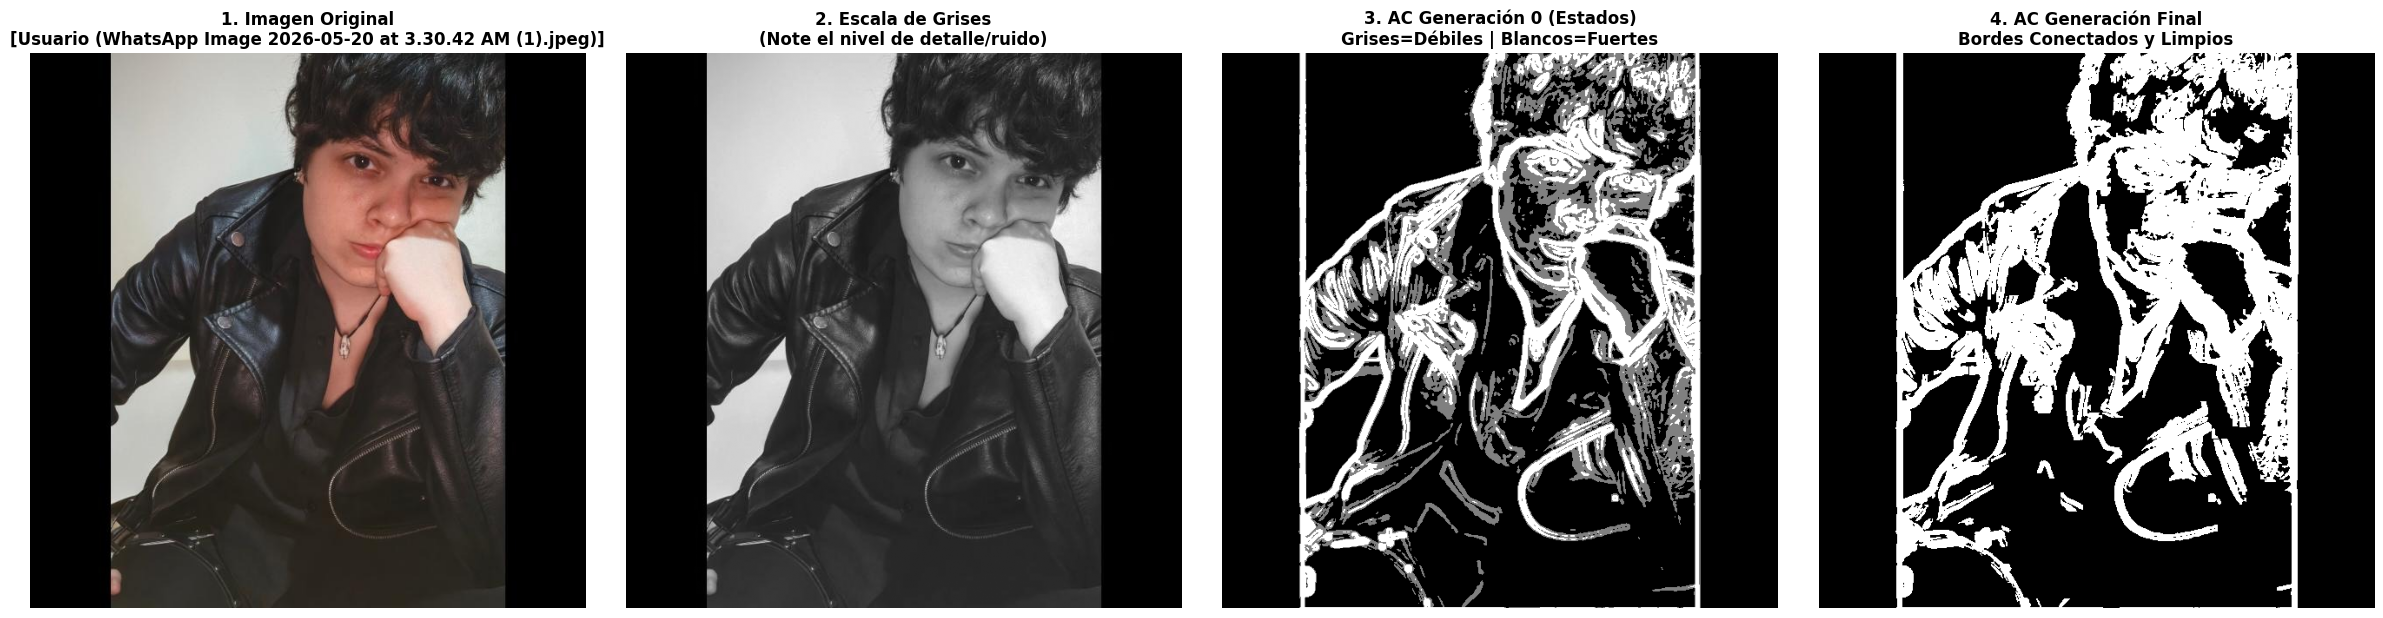

In [ ]:

# --- FUNCIÓN 1: INTERFAZ DE USUARIO Y CARGA (Con generador de ruido) ---
def obtener_imagen_procesamiento():
    print("=========================================================")
    print("   SISTEMA DE DETECCIÓN DE BORDES AVANZADO (AC + GAUSS)  ")
    print("=========================================================")

    respuesta = input("¿Deseas subir una foto desde tu equipo? (s/n): ").strip().lower()

    if respuesta == 's':
        try:
            print("\nPor favor, selecciona tu archivo en el recuadro de abajo:")
            subido = files.upload()
            if not subido:
                return generar_imagen_sintetica_ruidosa()

            nombre_archivo = list(subido.keys())[0]
            img_color = Image.open(io.BytesIO(subido[nombre_archivo])).convert('RGB')
            print(f"\n> Imagen '{nombre_archivo}' cargada.")
            return img_color, f"Usuario ({nombre_archivo})"

        except Exception as e:
            print(f"\n> Error ({e}). Generando imagen automática...")
            return generar_imagen_sintetica_ruidosa()
    else:
        return generar_imagen_sintetica_ruidosa()

def generar_imagen_sintetica_ruidosa():
    """Genera una imagen geométrica pero le inyecta ruido estático
    para poner a prueba el nuevo filtro gaussiano."""
    img = Image.new('RGB', (400, 400), color=(70, 130, 180))
    draw = ImageDraw.Draw(img)
    draw.rectangle([50, 50, 350, 350], fill=(255, 255, 255))
    draw.ellipse([120, 120, 280, 280], fill=(40, 40, 40))
    draw.ellipse([170, 170, 230, 230], fill=(255, 215, 0))

    # Inyectar ruido aleatorio
    matriz = np.array(img)
    ruido = np.random.randint(-40, 40, matriz.shape, dtype=np.int16)
    matriz_ruidosa = np.clip(matriz + ruido, 0, 255).astype(np.uint8)

    return Image.fromarray(matriz_ruidosa), "Sintética con Ruido"


# --- FUNCIÓN 2: MOTOR DE AC AVANZADO (GAUSS + ADAPTATIVO + HISTÉRESIS) ---
def aplicar_ca_bordes_avanzado(matriz_gris):
    """
    Motor AC en 3 fases: Preprocesamiento, Umbral Adaptativo y Evolución.
    """
    img_np = matriz_gris.astype(np.float32)

    # MEJORA 1: Filtro Gaussiano (Limpieza de Ruido)
    # Suaviza las texturas falsas antes de que el AC las lea.
    img_suavizada = gaussian_filter(img_np, sigma=1.5)

    # Desplazamientos para la Vecindad de Moore
    desplazamientos = [
        (-1, -1), (-1, 0), (-1, 1),
        ( 0, -1),          ( 0, 1),
        ( 1, -1), ( 1, 0), ( 1, 1)
    ]

    max_local = np.copy(img_suavizada)
    min_local = np.copy(img_suavizada)

    for di, dj in desplazamientos:
        vecino = np.roll(np.roll(img_suavizada, di, axis=0), dj, axis=1)
        max_local = np.maximum(max_local, vecino)
        min_local = np.minimum(min_local, vecino)

    # Calcular el gradiente morfológico
    gradiente = max_local - min_local


    umbral_fuerte = np.percentile(gradiente, 85)
    umbral_debil = umbral_fuerte * 0.35 # Los bordes más tenues (35% del fuerte)

    # Asignar 3 estados celulares: 0 (Fondo), 128 (Borde Débil), 255 (Borde Fuerte)
    estado_ca = np.zeros_like(gradiente, dtype=np.uint8)
    estado_ca[gradiente >= umbral_debil] = 128
    estado_ca[gradiente >= umbral_fuerte] = 255

    candidatos_iniciales = np.copy(estado_ca) # Guardar para la gráfica (Etapa 3)

    # MEJORA 3: Evolución Multigeneracional del Autómata (Histéresis)
    # Regla: Un "Borde Débil" (128) se convierte en "Fuerte" (255) SOLO SI toca a otro borde fuerte.
    generaciones = 10

    for gen in range(generaciones):
        # Crear un mapa de dónde están los bordes fuertes actuales
        vecinos_fuertes = np.zeros_like(estado_ca, dtype=bool)

        for di, dj in desplazamientos:
            # Buscar vecinos que sean igual a 255
            vecino_fuerte = np.roll(np.roll(estado_ca == 255, di, axis=0), dj, axis=1)
            vecinos_fuertes = vecinos_fuertes | vecino_fuerte

        # Aplicar la regla de vida: Débil + vecino fuerte = Revive como Fuerte
        celdas_a_revivir = (estado_ca == 128) & vecinos_fuertes

        # Si ninguna célula cambió en esta generación, el AC se estabilizó
        if not np.any(celdas_a_revivir):
            break

        estado_ca[celdas_a_revivir] = 255

    # Regla de muerte final: Las células débiles que no se conectaron a nada, mueren (ruido).
    estado_ca[estado_ca == 128] = 0

    return candidatos_iniciales, estado_ca


# --- FUNCIÓN 3: VISUALIZACIÓN COMPARATIVA EN 4 ETAPAS ---
def mostrar_proceso_avanzado(img_original, candidatos_ca, final_ca, nombre):
    fig, ejes = plt.subplots(1, 4, figsize=(24, 6))

    # 1. Original (Puede tener ruido)
    ejes[0].imshow(img_original)
    ejes[0].set_title(f"1. Imagen Original\n[{nombre}]", fontsize=12, fontweight='bold')
    ejes[0].axis('off')

    # 2. Escala de grises (Visualización estándar)
    ejes[1].imshow(img_original.convert('L'), cmap='gray')
    ejes[1].set_title("2. Escala de Grises\n(Note el nivel de detalle/ruido)", fontsize=12, fontweight='bold')
    ejes[1].axis('off')

    # 3. Estados Iniciales del AC (Fuertes y Débiles)
    # Se verán píxeles grises (débiles) y blancos (fuertes)
    ejes[2].imshow(candidatos_ca, cmap='gray')
    ejes[2].set_title("3. AC Generación 0 (Estados)\nGrises=Débiles | Blancos=Fuertes", fontsize=12, fontweight='bold')
    ejes[2].axis('off')

    # 4. Resultado tras la evolución
    ejes[3].imshow(final_ca, cmap='gray')
    ejes[3].set_title("4. AC Generación Final\nBordes Conectados y Limpios", fontsize=12, fontweight='bold')
    ejes[3].axis('off')

    plt.tight_layout()
    plt.show()

# =========================================================================
# EJECUCIÓN DEL PIPELINE
# =========================================================================
try:
    # 1. Cargar o generar
    img_original, fuente_nombre = obtener_imagen_procesamiento()

    # 2. Convertir a matriz gris
    matriz_gris = np.array(img_original.convert('L'))

    # 3. Aplicar AC Avanzado
    ca_inicial, ca_final = aplicar_ca_bordes_avanzado(matriz_gris)

    # 4. Mostrar etapas
    mostrar_proceso_avanzado(img_original, ca_inicial, ca_final, fuente_nombre)

except Exception as e:
    print(f"\n[ERROR]: Ocurrió un fallo: {e}")

## Documentación del código

#### `obtener_imagen_procesamiento()`
**Descripción:** Función principal de interfaz de usuario que decide la fuente de la imagen a procesar. Pregunta al usuario si desea subir una imagen desde su equipo; en caso afirmativo invoca el cargador de archivos de Google Colab, lee la imagen, la convierte a RGB y retorna la imagen junto con un nombre descriptivo. Si ocurre un error o el usuario responde negativamente, genera una imagen sintética con ruido mediante `generar_imagen_sintetica_ruidosa()`.

**Funciones de librería utilizadas:**
- **`input(...)` (función incorporada de Python):**  
  Muestra un mensaje y espera una entrada de texto del usuario.
- **`str.strip().lower()`:**  
  Limpia espacios y convierte a minúsculas para normalizar la respuesta.
- **`files.upload()` (de `google.colab.files`, típico en Colab):**  
  Abre un diálogo de selección de archivos en el navegador. Retorna un diccionario con nombres de archivo como claves y contenido en bytes como valores. Si no se selecciona nada, devuelve un diccionario vacío.
- **`list(subido.keys())[0]`:**  
  Obtiene el nombre del primer archivo subido.
- **`Image.open(io.BytesIO(subido[nombre_archivo]))` (de PIL/Pillow):**  
  Abre una imagen desde un flujo de bytes en memoria. `io.BytesIO` envuelve los datos binarios como un archivo. `Image.open` detecta el formato y crea un objeto `Image` de Pillow.
- **`.convert('RGB')`:**  
  Convierte la imagen a modo RGB (tres canales de 8 bits), asegurando compatibilidad incluso si la original tiene transparencia o escala de grises.
- **`generar_imagen_sintetica_ruidosa()` (función propia, descrita más abajo):**  
  Genera una imagen de prueba con ruido sintético.

---

#### `generar_imagen_sintetica_ruidosa()`
**Descripción:** Crea una imagen geométrica de 400×400 píxeles (fondo azul acero, rectángulo blanco, dos círculos concéntricos gris oscuro y amarillo) y luego inyecta ruido aleatorio uniforme de ±40 niveles de intensidad por canal, recortando valores al rango 0–255. Retorna la imagen ruidosa y la cadena identificativa `"Sintética con Ruido"`. El ruido simula imperfecciones reales para probar la robustez del filtro gaussiano y del autómata celular posterior.

**Funciones de librería utilizadas:**
- **`Image.new('RGB', (400, 400), color=(70, 130, 180))`:**  
  Crea una nueva imagen RGB rellena con el color azul acero. Internamente asigna un lienzo de 400×400 con tres canales.
- **`ImageDraw.Draw(img)`:**  
  Prepara un objeto de dibujo vectorial sobre la imagen. Las operaciones de dibujo (rectángulos, elipses) se rasterizan directamente sobre los píxeles de la imagen original.
- **`draw.rectangle([...], fill=...)` y `draw.ellipse([...], fill=...)`:**  
  Dibuja formas rellenas con el color indicado.
- **`np.array(img)`:**  
  Convierte la imagen PIL en un arreglo NumPy de forma `(alto, ancho, canales)`. Cada canal es un entero sin signo de 8 bits.
- **`np.random.randint(-40, 40, matriz.shape, dtype=np.int16)`:**  
  Genera un arreglo de ruido entero entre -40 y 39 con la misma forma que la imagen. Se usa `int16` para permitir valores negativos.
- **`np.clip(matriz + ruido, 0, 255).astype(np.uint8)`:**  
  Suma el ruido a la matriz original, trunca valores fuera del rango 0–255 y convierte a `uint8`.
- **`Image.fromarray(matriz_ruidosa)`:**  
  Reconstruye una imagen PIL desde el arreglo NumPy modificado.

---

#### `aplicar_ca_bordes_avanzado(matriz_gris)`
**Descripción:** Motor de detección de bordes basado en autómata celular (AC) que opera en tres fases: (1) suavizado gaussiano para eliminar ruido; (2) cálculo de gradiente morfológico y umbral adaptativo (percentil 85) para clasificar píxeles en fondo (0), borde débil (128) y borde fuerte (255); (3) evolución multigeneracional del AC con regla de histéresis: un borde débil solo sobrevive si toca un borde fuerte. Retorna dos arreglos: los estados iniciales del AC (`candidatos_iniciales`) y los estados finales después de la convergencia (`estado_ca`).

**Funciones de librería utilizadas:**
- **`matriz_gris.astype(np.float32)`:**  
  Convierte la imagen en escala de grises a punto flotante de 32 bits para operaciones de suavizado con precisión.
- **`gaussian_filter(img_np, sigma=1.5)` (de `scipy.ndimage`):**  
  Aplica un filtro gaussiano isotrópico con desviación estándar σ=1.5. Realiza una convolución discreta con un kernel gaussiano truncado. Suaviza la imagen reduciendo el ruido de alta frecuencia sin desdibujar bordes marcados.
- **Definición de `desplazamientos` (lista de tuplas):**  
  Vecindad de Moore (8‑conectada). Se usan para desplazar la imagen en todas direcciones.
- **`np.roll(img_suavizada, di, axis=0)` y `np.roll(..., dj, axis=1)`:**  
  Desplaza cíclicamente la matriz a lo largo de filas y columnas. Para cada desplazamiento se obtiene la vista de un vecino. En los bordes, los píxeles se envuelven (esto no afecta porque luego se calculan máximo/mínimo locales y se usan solo en el interior conceptualmente; el envoltorio es aceptable para la vecindad).
- **`np.maximum(max_local, vecino)` y `np.minimum(...)`:**  
  Comparan elemento a elemento dos arreglos y retornan el máximo/mínimo en cada posición. Acumulan el máximo y el mínimo locales en la vecindad.
- **`gradiente = max_local - min_local`:**  
  Gradiente morfológico: diferencia entre el máximo y el mínimo en la vecindad de cada píxel. Realza transiciones.
- **`np.percentile(gradiente, 85)`:**  
  Calcula el percentil 85 del arreglo `gradiente`. Ordena virtualmente todos los valores y devuelve aquel bajo el cual cae el 85% de los datos. Este umbral adaptativo evita depender de constantes fijas.
- **`umbral_debil = umbral_fuerte * 0.35`:**  
  Define el umbral débil como el 35% del fuerte.
- **Asignación de estados con máscaras booleanas (`estado_ca[gradiente >= umbral_debil] = 128`, etc.):**  
  Indexado booleano de NumPy: asigna un valor constante a todos los píxeles donde la condición es verdadera.
- **Evolución del AC (bucle `for gen in range(generaciones)`):**
  - **`np.roll(estado_ca == 255, di, axis=0)`:** Crea una máscara booleana de los bordes fuertes desplazada.
  - **`vecinos_fuertes = vecinos_fuertes | vecino_fuerte`:** Acumula con operador OR bit a bit la presencia de algún vecino fuerte.
  - **`celdas_a_revivir = (estado_ca == 128) & vecinos_fuertes`:** Identifica bordes débiles que tienen al menos un vecino fuerte.
  - **`estado_ca[celdas_a_revivir] = 255`:** Promueve esas células a borde fuerte.
  - **`if not np.any(celdas_a_revivir): break`:** Si no hay cambios, el AC se estabiliza y se sale del bucle.
- **`estado_ca[estado_ca == 128] = 0`:** Elimina los bordes débiles que no se conectaron, considerados ruido.

---

#### `mostrar_proceso_avanzado(img_original, candidatos_ca, final_ca, nombre)`
**Descripción:** Muestra un panel comparativo de 4 etapas del pipeline: (1) imagen original a color, (2) escala de grises, (3) estados iniciales del AC (gris = débil, blanco = fuerte) y (4) resultado final después de la evolución. Utiliza `matplotlib` para la visualización.

**Funciones de librería utilizadas:**
- **`plt.subplots(1, 4, figsize=(24, 6))`:**  
  Crea una figura con una fila y cuatro columnas de ejes, de 24×6 pulgadas.
- **`ejes[i].imshow(...)`:**  
  Muestra una imagen en el subgráfico correspondiente.
  - En el primer panel, `img_original` es una imagen PIL RGB; `imshow` la normaliza automáticamente.
  - En los paneles 2, 3 y 4 se usa `cmap='gray'` para visualizar en escala de grises.
- **`img_original.convert('L')`:**  
  Convierte la imagen original a modo luminosidad (escala de grises) usando la fórmula perceptual de Pillow.
- **`.set_title(...)`:**  
  Asigna un título a cada subgráfico.
- **`.axis('off')`:**  
  Oculta los ejes.
- **`plt.tight_layout()` y `plt.show()`:**  
  Ajusta espacios y muestra la figura.

---

#### Código principal de ejecución
**Descripción:** Bloque que orquesta el pipeline: (1) obtiene la imagen y su nombre, (2) la convierte a matriz gris, (3) aplica el autómata celular avanzado y (4) muestra el proceso completo. Está envuelto en un bloque `try-except` para capturar cualquier excepción y mostrar un mensaje de error.

**Funciones de librería utilizadas:**
- **`np.array(img_original.convert('L'))`:** Convierte la imagen a grises y luego a arreglo NumPy 2D.
- Las demás funciones llamadas ya fueron documentadas.

---

*Documentación de las nuevas funciones del sistema de detección de bordes con autómata celular, filtro gaussiano y umbral adaptativo.*



# Informe de artículo

## Informe de Revisión de Investigación: Autómatas Celulares



## 1. Referencia del trabajo

Reyes Gómez, D. A. (2011). *Descripción y Aplicaciones de los Autómatas Celulares*. Verano de Investigación 2011, Departamento de Aplicación de Microcomputadoras, Universidad Autónoma de Puebla. FES Acatlán, U. N. A. M.

## 2. Resumen del trabajo

El artículo presenta una revisión general sobre los Autómatas Celulares (AC), definidos como modelos matemáticos para sistemas dinámicos discretos compuestos por un arreglo de células que evolucionan en el tiempo regidas por una regla de transición local. Surgidos en la década de 1940 con John Von Neumann, los AC se caracterizan por su capacidad para generar propiedades emergentes y complejas a partir de reglas simples y comportamientos locales.

El autor detalla los elementos fundamentales de un AC (arreglo regular, conjunto de estados, configuración inicial, vecindades y función local) y explora sus aplicaciones en diversas disciplinas:

- **Arquitectura:** Generación de patrones y formas tridimensionales complejas a través de métodos recursivos, superposición de células y variación de escalas.
- **Bioinformática:** Modelado de sistemas biológicos complejos (como la morfogénesis y la auto-organización) donde las ecuaciones diferenciales parciales resultan insuficientes o computacionalmente costosas, incluyendo la simulación de redes neuronales y el funcionamiento cerebral.
- **Control de Incendios Forestales:** Simulación de la propagación del fuego en matrices bidimensionales, considerando variables como la velocidad y dirección del viento, y la densidad del bosque.
- **Criptografía:** Uso de AC (como la Regla 30 de Wolfram) para la generación de secuencias pseudoaleatorias que funcionan como claves para el cifrado simétrico de mensajes, aprovechando la impredicibilidad y la reversibilidad de ciertos autómatas.

## 3. Descripción de los indicadores o métricas (Aplicación en la evaluación/obtención de mediciones experimentales)

En el contexto de los Autómatas Celulares, la obtención y evaluación de mediciones no se realiza mediante instrumentos físicos tradicionales, sino a través de la simulación *in silico*, donde el AC actúa como un "laboratorio virtual". El artículo ilustra cómo se definen y evalúan las métricas dependiendo del fenómeno modelado:

### A. Métricas en la Simulación de Incendios Forestales

En esta aplicación, el AC permite medir y evaluar el impacto del fuego bajo diferentes condiciones iniciales:

- **Densidad del bosque:** Parámetro inicial que mide la cantidad de árboles (células ocupadas) en la matriz \(N \times N\).
- **Velocidad y dirección del viento:** Variables discretizadas (velocidad: 0, 1, 2; dirección: 8 puntos cardinales) que modifican la vecindad efectiva de la célula en combustión.
- **Tasa de supervivencia:** Métrica de resultado que mide el porcentaje de la población de árboles que sobrevive al incendio. (El artículo cita que con viento nulo, la supervivencia es menor al 10%).
- **Tiempo de extinción:** Duración (en iteraciones discretas) del incendio, el cual es proporcional a la cantidad de árboles destruidos.
- **Resistencia/Combustibilidad de la madera:** Medida a través del número de intervalos de tiempo que tarda una célula en transicionar del estado inicial al de calcinado.

### B. Métricas en Criptografía

Aquí, las métricas evalúan la seguridad y eficiencia del criptosistema basado en AC (específicamente la Regla 30):

- **Longitud de la clave (bits):** Tamaño del arreglo inicial. El artículo advierte que claves entre 300 y 500 bits son vulnerables, recomendando métricas superiores a 1000 bits para garantizar la seguridad.
- **Grado de aleatoriedad:** Métrica cualitativa y cuantitativa que evalúa la impredicibilidad de la secuencia generada por el AC. La ausencia de patrones repetidos o simetría en la evolución del AC es el indicador visual y matemático de una buena aleatoriedad.
- **Irreversibilidad/Reversibilidad:** Propiedad medida por la capacidad de invertir la regla de evolución (ej. Regla 85 invertida por la Regla 15) para recuperar el mensaje original sin pérdida de información.

### C. Métricas en Arquitectura

- **Conectividad y Soporte Vertical:** Métricas estructurales que evalúan si las células generadas por el AC están conectadas horizontalmente o poseen soporte hacia el suelo, descartando configuraciones "construcciones imposibles".
- **Área interior y traslape:** Variación en la distancia entre los centros de las células para maximizar el espacio interior habitable.

### D. Métricas en Bioinformática

- **Patrones de auto-organización (ej. Patrones de Turing):** Evaluación visual y matemática de la emergencia de formas (como manchas en la piel de animales) a partir de reglas locales, midiendo la correspondencia entre el modelo AC y la observación biológica real.

## 4. Conclusiones personales (Capacidad de análisis crítico)

El artículo demuestra de manera contundente que los Autómatas Celulares son una herramienta poderosa para la obtención de mediciones experimentales en sistemas donde la experimentación física es inviable, costosa o peligrosa (como incendios forestales masivos o el estudio del cerebro vivo).

**Análisis crítico sobre la metodología de medición:**  
La fortaleza metodológica de los AC radica en su capacidad de discretizar fenómenos continuos complejos, permitiendo el aislamiento de variables (ej. modificar solo la velocidad del viento en un incendio) para observar su efecto causal en el sistema. Sin embargo, esto conlleva un riesgo fundamental: la calidad de la medición experimental depende enteramente de la correcta definición de la regla de transición local. Si la regla no captura la esencia física o biológica del fenómeno (por ejemplo, si omite la humedad del suelo en el incendio), las métricas obtenidas serán precisas matemáticamente, pero irrelevantes empíricamente.

**Sobre la aplicación en Criptografía:**  
El uso de la Regla 30 como generador de secuencias pseudoaleatorias es un ejemplo elegante de cómo la complejidad emergente de un AC se convierte en un recurso medible (la entropía de la clave). No obstante, la advertencia del autor sobre la longitud de la clave (>1000 bits) subraya una debilidad práctica: la seguridad de estos sistemas está limitada por el poder computacional moderno de criptoanálisis, lo que obliga a que las métricas de seguridad sean revisadas constantemente.

**Reflexión final:**  
Los AC validan un paradigma científico donde la "medición" proviene de la simulación. Como bien concluye el autor, la verdadera riqueza no está en los resultados numéricos aislados, sino en el proceso dinámico que los genera. La capacidad de los AC para modelar desde la evolución genética hasta la arquitectura sugiere que la naturaleza misma podría operar bajo principios computacionales similares, posicionando a los AC no solo como una herramienta de medición, sino como una posible metateoría de la complejidad del universo.

#bonus: incendio forestal

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors
import matplotlib.gridspec as gridspec
from scipy.signal import convolve2d
from IPython.display import HTML

# Unificamos el uso de la semilla aleatoria en numpy
np.random.seed()


TAMANIO_GRID = 100
DENSIDAD_ARBOLES = 0.65
PROB_REGENERACION = 0.05
PROB_RAYO = 0.0005
PASOS_SIMULACION = 300

# Estados
VACIO = 0
ARBOL = 1
LLAMAS = 2

# Estética
COLORES_GOL = ['black', '#00FF00', '#FF0000']

# Kernel de Von Neumann (Arriba, Abajo, Izquierda, Derecha)
KERNEL_VON_NEUMANN = np.array([[0, 1, 0],
                               [1, 0, 1],
                               [0, 1, 0]])


grid = np.zeros((TAMANIO_GRID, TAMANIO_GRID), dtype=int)
mascara_arboles = np.random.random((TAMANIO_GRID, TAMANIO_GRID)) < DENSIDAD_ARBOLES
grid[mascara_arboles] = ARBOL

centro = TAMANIO_GRID // 2
grid[centro-1:centro+2, centro-1:centro+2] = LLAMAS

# Grid perturbado para calcular el Exponente de Lyapunov
grid_shadow = np.copy(grid)
grid_shadow[0, 0] = ARBOL if grid_shadow[0, 0] == VACIO else VACIO

# Historial para las gráficas
historial_langton = []
historial_densidad = []
historial_hamming = []
historial_lyapunov = []
historial_ent_espacial = []
historial_ent_temporal = []

grid_anterior = None


def aplicar_reglas(grid_actual):
    # Crear una matriz binaria donde 1 significa "hay llamas"
    llamas_mask = (grid_actual == LLAMAS).astype(int)

    # Contar cuántos vecinos en llamas tiene cada celda usando convolución
    vecinos_en_llamas = convolve2d(llamas_mask, KERNEL_VON_NEUMANN, mode='same', boundary='fill', fillvalue=0)

    # Matrices booleanas para los estados actuales
    es_arbol = (grid_actual == ARBOL)
    es_vacio = (grid_actual == VACIO)
    es_llamas = (grid_actual == LLAMAS)

    # Matrices de probabilidades
    rayos = np.random.random(grid_actual.shape) < PROB_RAYO
    regeneracion = np.random.random(grid_actual.shape) < PROB_REGENERACION

    nuevo_grid = np.copy(grid_actual)

    # 1. Árboles se queman si un vecino arde O cae un rayo
    nuevo_grid[es_arbol & ((vecinos_en_llamas > 0) | rayos)] = LLAMAS

    # 2. Espacios vacíos regeneran árboles
    nuevo_grid[es_vacio & regeneracion] = ARBOL

    # 3. Llamas se apagan (pasan a vacío)
    nuevo_grid[es_llamas] = VACIO

    return nuevo_grid


def calcular_parametros(g_actual, g_anterior, g_perturbado):
    total = TAMANIO_GRID * TAMANIO_GRID

    # 1. Parámetro de Langton
    langton = np.sum(g_actual != VACIO) / total

    # 2. Densidad de Árboles
    densidad = np.sum(g_actual == ARBOL) / total

    # 3. Distancia de Hamming
    hamming = np.sum(g_actual != g_anterior) / total if g_anterior is not None else 0.0

    # 4. Exponente de Lyapunov
    d_lyap = np.sum(g_actual != g_perturbado) / total
    lyapunov = np.log(d_lyap + 1e-10)

    # 5. Entropía Espacial
    counts = np.bincount(g_actual.flatten(), minlength=3)
    probs = counts[counts > 0] / total
    ent_espacial = -np.sum(probs * np.log2(probs))

    # 6. Entropía Temporal
    if g_anterior is not None:
        transiciones = g_anterior * 3 + g_actual
        trans_counts = np.bincount(transiciones.flatten(), minlength=9)
        trans_probs = trans_counts[trans_counts > 0] / total
        ent_temporal = -np.sum(trans_probs * np.log2(trans_probs))
    else:
        ent_temporal = 0.0

    return langton, densidad, hamming, lyapunov, ent_espacial, ent_temporal


fig = plt.figure(figsize=(16, 8), facecolor='black')
gs = gridspec.GridSpec(3, 3, width_ratios=[1.5, 1, 1], hspace=0.4, wspace=0.3)

# Subplot principal
ax_grid = fig.add_subplot(gs[:, 0])
ax_grid.set_facecolor('black')
cmap_gol = matplotlib.colors.ListedColormap(COLORES_GOL)
img = ax_grid.imshow(grid, cmap=cmap_gol, vmin=0, vmax=2)
ax_grid.axis('off')
titulo = ax_grid.set_title('Generación: 0', color='white', fontsize=12, pad=10)

# Subplots para métricas
ejes_layout = [
    (gs[0, 1], 'Parámetro de Langton', 'cyan'),
    (gs[0, 2], 'Densidad Árboles', 'lime'),
    (gs[1, 1], 'Distancia de Hamming', 'yellow'),
    (gs[1, 2], 'Exponente Lyapunov (Log)', 'magenta'),
    (gs[2, 1], 'Entropía Espacial', 'orange'),
    (gs[2, 2], 'Entropía Temporal', 'red')
]

ejes = []
lineas = []

for pos, title, color in ejes_layout:
    ax = fig.add_subplot(pos)
    ax.set_facecolor('#1a1a1a')
    ax.set_title(title, color='white', fontsize=9)
    ax.tick_params(colors='white', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('gray')
    linea, = ax.plot([], [], color=color, linewidth=1.5)
    ejes.append(ax)
    lineas.append(linea)


def actualizar_generacion(frame):
    global grid, grid_shadow, grid_anterior

    grid_anterior_temp = np.copy(grid)

    grid = aplicar_reglas(grid)
    grid_shadow = aplicar_reglas(grid_shadow)

    langton, densidad, hamming, lyapunov, ent_espacial, ent_temporal = calcular_parametros(
        grid, grid_anterior, grid_shadow
    )

    grid_anterior = grid_anterior_temp
    historial_langton.append(langton)
    historial_densidad.append(densidad)
    historial_hamming.append(hamming)
    historial_lyapunov.append(lyapunov)
    historial_ent_espacial.append(ent_espacial)
    historial_ent_temporal.append(ent_temporal)

    img.set_data(grid)
    titulo.set_text(f'Generación: {frame+1}')

    historiales = [historial_langton, historial_densidad, historial_hamming,
                   historial_lyapunov, historial_ent_espacial, historial_ent_temporal]

    x_data = list(range(len(historial_langton)))
    for linea, hist, ax in zip(lineas, historiales, ejes):
        linea.set_data(x_data, hist)
        ax.set_xlim(0, max(10, len(hist)))
        if len(hist) > 1:
            y_min, y_max = min(hist), max(hist)
            margin = max(0.01, (y_max - y_min) * 0.1) # Evitamos margen cero
            ax.set_ylim(y_min - margin, y_max + margin)

    return [img, titulo] + lineas

ani = animation.FuncAnimation(fig, actualizar_generacion, frames=PASOS_SIMULACION,
                              interval=60, blit=False, repeat=False)


plt.close()
HTML(ani.to_jshtml())

## Documentación del Simulador de Incendios Forestales con Autómata Celular

#### Constantes y configuración inicial
**Descripción:** Define los parámetros globales del modelo de incendio forestal y prepara el estado inicial. Se establecen el tamaño de la cuadrícula (`TAMANIO_GRID = 100`), la densidad inicial de árboles (`DENSIDAD_ARBOLES = 0.65`), la probabilidad de regeneración de un sitio vacío (`PROB_REGENERACION = 0.05`), la probabilidad de que caiga un rayo sobre un árbol (`PROB_RAYO = 0.0005`) y el número total de pasos de simulación (`PASOS_SIMULACION = 300`). Los estados celulares se codifican como `VACIO = 0`, `ARBOL = 1`, `LLAMAS = 2`. La semilla aleatoria de NumPy se inicializa con `np.random.seed()` (usa entropía del sistema). Luego se genera una cuadrícula con árboles colocados aleatoriamente según la densidad y se sitúa un foco de llamas de 3×3 en el centro. Además, se crea un grid ligeramente perturbado (`grid_shadow`) para el cálculo del exponente de Lyapunov, cambiando el estado de la celda `(0,0)`. Finalmente se inicializan listas para almacenar el historial de métricas.

**Funciones de librería utilizadas:**
- **`np.random.seed()`:** Inicializa el generador pseudoaleatorio con una fuente no determinista (reloj del sistema u otra entropía), haciendo que cada ejecución produzca resultados distintos.
- **`np.random.random((TAMANIO_GRID, TAMANIO_GRID)) < DENSIDAD_ARBOLES`:** Genera una matriz de números aleatorios uniformes en [0,1) y crea una máscara booleana donde los valores son menores que la densidad, determinando así las posiciones iniciales de los árboles.
- **`np.zeros((TAMANIO_GRID, TAMANIO_GRID), dtype=int)`:** Crea la cuadrícula base rellena de ceros (estado VACÍO).
- **`grid[mascara_arboles] = ARBOL`:** Asigna el estado ARBOL (1) a las posiciones indicadas por la máscara.
- **`grid[centro-1:centro+2, centro-1:centro+2] = LLAMAS`:** Establece una región de 3×3 en el centro con el estado LLAMAS.
- **`np.copy(grid)`:** Realiza una copia independiente del grid para la versión perturbada.
- Operador ternario condicional: `ARBOL if grid_shadow[0,0] == VACIO else VACIO` invierte el estado de la celda (0,0) para crear una diferencia mínima.

---

#### `aplicar_reglas(grid_actual)`
**Descripción:** Ejecuta un paso de evolución del autómata celular siguiendo las reglas del modelo de incendio forestal:
1. Un árbol se convierte en llama si al menos un vecino (en la vecindad de Von Neumann) está ardiendo o si le cae un rayo (probabilidad `PROB_RAYO`).
2. Un sitio vacío puede regenerar un árbol con probabilidad `PROB_REGENERACION`.
3. Una célula en llamas pasa al estado vacío en el siguiente turno (se apaga).
La función utiliza convolución para contar eficientemente los vecinos en llamas.

**Funciones de librería utilizadas:**
- **`(grid_actual == LLAMAS).astype(int)`:** Crea una matriz binaria (0/1) que marca las posiciones con fuego. La conversión a entero permite la convolución.
- **`convolve2d(llamas_mask, KERNEL_VON_NEUMANN, mode='same', boundary='fill', fillvalue=0)` (de `scipy.signal`):** Realiza la convolución 2D discreta de la máscara de llamas con un kernel de Von Neumann (cruz). `mode='same'` devuelve una salida del mismo tamaño que la entrada. `boundary='fill'` con `fillvalue=0` trata los bordes como si estuvieran rodeados de ceros (sin fuego fuera de la cuadrícula). El resultado es una matriz donde cada celda contiene el número de vecinos en llamas.
- **`np.random.random(grid_actual.shape) < PROB_RAYO`** y análogo para `PROB_REGENERACION`: Generan máscaras booleanas con las posiciones donde ocurren eventos aleatorios según las probabilidades dadas.
- **`np.copy(grid_actual)`:** Crea una copia para el nuevo estado, sobre la que se aplican las transiciones.
- Asignaciones condicionales con máscaras booleanas (`nuevo_grid[condicion] = estado`): Modifican solo las celdas que cumplen la condición, típica indexación booleana de NumPy.

---

#### `calcular_parametros(g_actual, g_anterior, g_perturbado)`
**Descripción:** Calcula seis métricas cuantitativas que caracterizan el estado actual del sistema y su evolución, comparando la generación actual con la anterior y con un grid perturbado.
- **Parámetro de Langton:** proporción de celdas no vacías (árboles + llamas) sobre el total.
- **Densidad de árboles:** fracción de celdas ocupadas por árboles.
- **Distancia de Hamming:** fracción de celdas que cambiaron de estado respecto a la generación anterior (0.0 si no hay anterior).
- **Exponente de Lyapunov:** logaritmo natural de la fracción de celdas diferentes entre el grid actual y el perturbado, más una constante pequeña para evitar log(0). Aproxima la divergencia entre dos configuraciones inicialmente cercanas.
- **Entropía espacial:** entropía de Shannon de la distribución de los tres estados en la generación actual. Se ignoran los estados no presentes.
- **Entropía temporal:** entropía de Shannon de las transiciones entre estados entre la generación anterior y la actual, codificando cada par como `estado_anterior * 3 + estado_actual` (0–8). Si no hay anterior, es 0.0.

**Funciones de librería utilizadas:**
- **`np.sum(g_actual != VACIO) / total`:** Cuenta celdas no vacías y divide por el total de celdas.
- **`np.sum(g_actual == ARBOL) / total`:** Análogo para árboles.
- **`np.sum(g_actual != g_anterior) / total`:** Cantidad de cambios entre dos generaciones.
- **`np.log(d_lyap + 1e-10)`:** Logaritmo natural (base e) de la divergencia, con un pequeño offset para estabilidad numérica.
- **`np.bincount(g_actual.flatten(), minlength=3)`:** Cuenta la frecuencia de cada valor entero (0,1,2) en el array aplanado. `minlength=3` asegura que el resultado siempre tenga longitud 3.
- **`probs = counts[counts > 0] / total`:** Filtra los estados con frecuencia cero y calcula probabilidades.
- **`-np.sum(probs * np.log2(probs))`:** Calcula la entropía en bits (log base 2).
- **`g_anterior * 3 + g_actual`:** Codifica cada transición de estado como un único entero entre 0 y 8. Luego se usa `np.bincount` de manera similar para obtener las frecuencias de las transiciones.

---

#### `actualizar_generacion(frame)`
**Descripción:** Función callback invocada por la animación de Matplotlib en cada cuadro. Realiza un paso de evolución del modelo (grid principal y grid perturbado), calcula las seis métricas con la función `calcular_parametros`, las almacena en las listas de historial y actualiza tanto la imagen del autómata como las gráficas de líneas de las métricas en tiempo real.

**Funciones de librería utilizadas:**
- **`np.copy(grid)`:** Respalda el grid anterior antes de actualizarlo.
- **`aplicar_reglas(grid)` y `aplicar_reglas(grid_shadow)`:** Ejecutan la evolución de ambos grids.
- **`calcular_parametros(...)`:** Obtiene las métricas.
- **`img.set_data(grid)`:** Actualiza los datos de la imagen mostrada en el subplot principal.
- **`titulo.set_text(f'Generación: {frame+1}')`:** Cambia el título del subplot.
- **`linea.set_data(x_data, hist)`:** Actualiza los datos de cada gráfica de línea con el historial acumulado.
- **`ax.set_xlim(0, max(10, len(hist)))` y `ax.set_ylim(...)`:** Ajustan dinámicamente los límites de los ejes para acomodar los nuevos datos, añadiendo un margen del 10% (con un mínimo de 0.01) para evitar recorte.
- **`return [img, titulo] + lineas`:** Devuelve la lista de artistas modificados para que `FuncAnimation` pueda optimizar el redibujado (aunque en este código `blit=False`).

---

#### Configuración de la figura y animación
**Descripción:** Construye la figura de Matplotlib con un diseño de cuadrícula (`GridSpec`) de 3 filas y 3 columnas. El subplot izquierdo ocupa toda la altura y muestra el autómata. Los otros seis subplots muestran la evolución de las métricas, cada uno con un color distintivo y fondo oscuro. Luego se crea una animación (`FuncAnimation`) que llama a `actualizar_generacion` durante `PASOS_SIMULACION` cuadros, con un intervalo de 60 ms. Finalmente, la animación se convierte a HTML para ser incrustada en un notebook.

**Funciones de librería utilizadas:**
- **`plt.figure(figsize=(16,8), facecolor='black')`:** Crea la figura principal con fondo negro.
- **`gridspec.GridSpec(3, 3, width_ratios=[1.5,1,1], hspace=0.4, wspace=0.3)`:** Define una rejilla flexible; la primera columna es más ancha.
- **`fig.add_subplot(gs[:,0])`:** Añade el subplot principal que ocupa las 3 filas de la primera columna.
- **`matplotlib.colors.ListedColormap(COLORES_GOL)`:** Crea un mapa de colores discreto de tres colores (negro, verde, rojo) para representar VACÍO, ÁRBOL, LLAMAS.
- **`ax.imshow(grid, cmap=cmap_gol, vmin=0, vmax=2)`:** Muestra el grid como imagen con el mapa de colores personalizado.
- Configuración de estilos: `ax.set_facecolor(...)`, `spine.set_edgecolor(...)`, etc.
- **`animation.FuncAnimation(fig, actualizar_generacion, frames=PASOS_SIMULACION, interval=60, blit=False, repeat=False)`:** Crea la animación. `frames` es el número de iteraciones, `interval` es el retardo entre cuadros en milisegundos. `blit=False` redibuja todo cada cuadro (más simple pero menos eficiente).
- **`plt.close()`:** Cierra la figura para evitar que se muestre estática dos veces.
- **`HTML(ani.to_jshtml())` (de `IPython.display`):** Convierte la animación en una representación HTML/JavaScript y la muestra en un notebook. `ani.to_jshtml()` genera el código JS necesario para la reproducción.

---



# Presentación del artículo científico

# Informe de análisis: Uso de Autómatas Celulares en la simulación de reconstrucción de tejido nervioso

## Referencia bibliográfica del artículo

**Título:** Simulación del uso de motores moleculares como optimizador para la reconstrucción de tejido nervioso, a través de autómatas celulares  
**Autor:** Jesús Hernández  
**Institución:** Universidad Central de Venezuela, Facultad de Ciencias, Escuela de Física  
**Año:** 2014  
**Tipo de documento:** Trabajo especial de grado para optar al título de Licenciado en Física  
**Tutores:** Dr. Rafael Martin, Dra. Nuri Hurtado  
**Jurado:** Dr. Alfredo Marcano, Lic. Cesar Leal  

---

## Resumen del trabajo seleccionado

El trabajo de investigación utiliza el modelo matemático de **Autómatas Celulares (AC)** para estudiar la factibilidad del uso de motores moleculares especializados en la reorientación del crecimiento axonal, con el objetivo de reducir el tiempo de reconexión de axones fisurados en el sistema nervioso.

Se simularon dos sistemas:
- **Sistema Control (SC):** crecimiento natural de axones.
- **Sistema Intervenido (SI):** crecimiento asistido por motores moleculares que transportan señalizadores y guían el crecimiento.

La simulación se realizó en una cuadrícula de 300×300 celdas, dividida en dos subcuadrículas (150×300 cada una) para comparar ambos sistemas simultáneamente. Se definieron seis estados posibles para las celdas (motor libre, señalizador, axón sano, axón en crecimiento, motor anclado, celda vacía). Las reglas de evolución incluyeron movimiento browniano de motores y señalizadores, anclaje de motores al axón, y crecimiento dirigido del axón hacia señalizadores o motores anclados.

Se realizaron múltiples repeticiones (hasta 768) para obtener valores medios y errores asociados, evaluando:
- Tiempo promedio de reconexión (TRC)
- Velocidad de reconexión (VRC)
- Límite efectivo de motores para la reconexión

Los resultados mostraron que la intervención con motores moleculares reduce el TRC aproximadamente a la mitad, aumenta la velocidad de reconexión, y existe un número óptimo de motores a partir del cual no se obtienen mejoras adicionales.

---

## Descripción de las métricas utilizadas

El autor emplea varias métricas cuantitativas para evaluar el rendimiento de los sistemas simulados con Autómatas Celulares. A continuación se describen las principales:

### 1. Tiempo de Reconexión (TRC)
- **Definición:** Número de ciclos (pasos de evolución del AC) necesarios para que los dos extremos del axón fisurado se unan completamente.
- **Conversión:** 2800 ciclos = 1 día (basado en la tasa de crecimiento real de axones de hasta 5 mm/día).
- **Medición:** Se fijó una separación inicial entre extremos (DRC = 1.54 mm) y se ejecutó la simulación hasta lograr la unión. Se repitió 768 veces para obtener promedio y desviación estándar.
- **Comparación:** Se calculó TRC para SC y SI con el mismo DRC.

### 2. Velocidad de Reconexión (VRC)
- **Definición:** Tasa de cambio entre la distancia de separación inicial (DRC) y el tiempo de reconexión. Esencialmente, VRC = DRC / TRC.
- **Medición:** Se varió DRC desde 0.56 mm hasta 3.36 mm en incrementos de ΔDRC = 0.14 mm. Para cada valor se tomaron 10 medidas de TRC y se promediaron.
- **Análisis:** Se comparó la pendiente de la curva DRC vs TRC para SC (crecimiento lineal) y SI (crecimiento no lineal con saturación).

### 3. Límite Efectivo de Motores
- **Definición:** Número mínimo de motores moleculares necesario para alcanzar la máxima reducción posible en TRC para una distancia dada.
- **Medición:** Para seis distancias fijas (1.40, 1.75, 2.10, 2.45, 2.80, 3.15 mm) se incrementó la cantidad de motores desde 500 hasta 5500, en pasos de 250. Se midió TRC en cada configuración.
- **Identificación del límite:** Se observó un punto de saturación donde aumentar el número de motores ya no disminuye el TRC. Ese punto define el número óptimo para esa distancia.

### 4. Otras métricas auxiliares
- **Nº de ciclos:** Contador de pasos de evolución del AC.
- **Colisiones:** Número de encuentros entre señalizadores y el axón en crecimiento.
- **Uniones:** Indicador binario de si la reconexión se ha completado.
- **Motores anclados:** Número de motores que se han fijado al axón durante la simulación.

### 5. Validación estadística
- **Histogramas de contraste:** Superposición de 768 repeticiones para verificar la aleatoriedad del crecimiento (ausencia de caminos preferenciales).
- **Desviación estándar:** Calculada para el TRC, mostrando menor dispersión en el SI que en el SC.

---

## Conclusiones personales

### Sobre el uso de Autómatas Celulares en la obtención de medidas experimentales

El trabajo de Hernández demuestra que los Autómatas Celulares son una herramienta **válida y eficiente** para modelar sistemas biológicos complejos como el crecimiento neuronal. La discretización del espacio y el tiempo, característica fundamental de los AC, permite simular fenómenos que serían muy difíciles de estudiar experimentalmente debido a las escalas microscópicas y los largos tiempos involucrados.

**Fortalezas observadas:**
- Los AC permiten incorporar reglas locales simples que, al iterarse, generan comportamientos globales emergentes (como el crecimiento axonal errático).
- La capacidad de realizar cientos de repeticiones de forma automática proporciona robustez estadística, algo casi imposible en experimentos con animales.
- La implementación en Visual Basic con interfaz gráfica facilita la visualización en tiempo real y la modificación de parámetros, lo que convierte al modelo en una herramienta interactiva de exploración.

**Limitaciones reconocidas por el autor:**
- El modelo es una primera aproximación: no considera múltiples axones, diferentes tipos de neuronas, ni efectos tridimensionales.
- Se utilizó un solo tipo de señalizador y se ignoraron factores como temperatura, fluidos o resistencia del medio.
- El motor molecular propuesto es teórico; no se valida con datos experimentales reales de motores biológicos (kinesina, dineína, miosina).

**Análisis crítico de las métricas:**
Las métricas elegidas son apropiadas para los objetivos del estudio. El TRC y la VRC son medidas directas del rendimiento de la reconexión, y la exploración del límite efectivo de motores tiene implicaciones prácticas (evitar sobredosificación). Sin embargo, echo en falta:
- Una métrica de **eficiencia energética** (consumo de ATP por motor), relevante para una eventual aplicación in vivo.
- Una métrica de **precisión de la reconexión** (¿el axón reconecta con el objetivo correcto o forma conexiones erróneas?).
- Un análisis de **sensibilidad** a cambios en las reglas del AC (por ejemplo, variar la velocidad de movimiento browniano o el radio de vecindad).

**Relevancia del trabajo:**
Este estudio es un excelente ejemplo de **investigación interdisciplinaria** (física, biología, computación). Aunque es un trabajo de grado, su enfoque es novedoso: usar motores moleculares como "optimizadores" del crecimiento axonal es una idea que podría inspirar futuras terapias para lesiones nerviosas. La metodología basada en AC es replicable y extensible a otros problemas de regeneración tisular.

**Conclusión final:**
El uso de Autómatas Celulares permitió obtener medidas experimentales simuladas (TRC, VRC, límite de saturación) que serían muy costosas o éticamente problemáticas de obtener en modelos animales. El trabajo cumple con el objetivo de demostrar la factibilidad teórica de la intervención con motores moleculares, aunque se requieren validaciones biológicas y modelos más complejos antes de cualquier aplicación clínica. Personalmente, considero que esta investigación es un sólido punto de partida para líneas futuras que combinen la biocomputación y la neuroingeniería.